# Entity resolution vs. general-purpose language models

This notebook measures how well a Healthcare NLP entity resolver maps a plain clinical phrase to
the right code, side by side with several general-purpose language models, across four coding
systems: SNOMED CT, RxNorm, ICD-10-CM, and ICD-O-3.

Every phrase is written from clinical knowledge. Every gold code is checked against that coding system's own official public release file. Every language model answers through its own API, closed-book, with
no tools and no lookups. Run it top to bottom and you get a fully reproducible version of this comparison,
computed live against whatever release files and API keys you provide.

## What you need

- A Healthcare NLP license (`spark_jsl.json`, or the individual `SECRET` / `SPARK_NLP_LICENSE` /
  `JSL_VERSION` values). Every resolver below loads through `.pretrained()`, so no model file
  ships with this notebook.
- API keys for whichever language models you want in the comparison: Anthropic, OpenAI, Google.
  Each is optional. Skip a key and that model is left out of the report instead of failing the run.
- The official release files for the systems you want to test, downloaded through your own free
  registration where one is required. The exact file names and where to get them are listed at
  the start of each system's section:

| System | Source | Registration |
|---|---|---|
| ICD-10-CM | CMS | none |
| RxNorm | NLM / UMLS | free UMLS account |
| SNOMED CT (US Edition) | NLM / UMLS | free UMLS account |
| ICD-O-3 | EU Joint Research Centre, ICDO3_O ontology | none |

A standard Colab CPU runtime is enough for all four resolvers here.

## How this notebook is laid out

1. **Setup.** Install Spark NLP and Healthcare NLP, install the LLM SDKs, start Spark.
2. **API keys.** One cell per provider, each skippable.
3. **The four systems.** Gold sets and resolver settings, fixed and already verified.
4. **Ground truth.** For each system: get the official file, parse it, check every gold code
   against it. No private database anywhere in this notebook.
5. **Run the resolver.** `.pretrained()`, one system at a time, same pipeline shape for all four.
6. **Run the language models.** One closed-book API call per model per system.
7. **Score and report.** One combined table across all four systems, computed from what just ran.


## 1. Setup

Upload your license file once. If you already hold `SECRET`, `SPARK_NLP_LICENSE`, and
`JSL_VERSION` as plain values instead of a JSON file, set them directly and skip the upload.


In [ ]:
import json
import os

from google.colab import files

if "spark_jsl.json" not in os.listdir():
    uploaded = files.upload()
    os.rename(list(uploaded.keys())[0], "spark_jsl.json")

with open("spark_jsl.json") as f:
    license_keys = json.load(f)

locals().update(license_keys)
os.environ.update(license_keys)
print("License loaded:", "SECRET" in os.environ, "SPARK_NLP_LICENSE" in os.environ)


Saving spark_jsl_641.json to spark_jsl_641.json
License loaded: True True


In [ ]:
# Spark NLP + Healthcare NLP
!pip install --upgrade -q pyspark==3.4.0 spark-nlp==$PUBLIC_VERSION
!pip install --upgrade -q spark-nlp-jsl==$JSL_VERSION --extra-index-url https://pypi.johnsnowlabs.com/$SECRET

# The three LLM SDKs this notebook can call. Installing all three costs a few seconds either way --
# which providers actually run is decided later, by which API key you set.
!pip install --upgrade -q anthropic openai google-genai


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 MB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 kB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 27.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.2 requires pyspark[connect]~=4.0.0, but you have pyspark 3.4.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.5/581.5 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pyspark.ml import Pipeline, PipelineModel
from pyspark.sql import SparkSession
from sparknlp.annotator import *
from sparknlp.base import *
from sparknlp_jsl.annotator import *
import sparknlp_jsl
import sparknlp

params = {
    "spark.driver.memory": "32G",
    "spark.kryoserializer.buffer.max": "2000M",
    "spark.driver.maxResultSize": "8000M",
}
spark = sparknlp_jsl.start(license_keys["SECRET"], params=params, gpu=False)
print("Spark NLP     :", sparknlp.version())
print("Spark NLP JSL :", sparknlp_jsl.version())


Spark NLP     : 6.4.2
Spark NLP JSL : 6.4.1


## 2. API keys

Each provider stands on its own. Add a Colab secret named `ANTHROPIC_API_KEY`, `OPENAI_API_KEY`,
or `GOOGLE_API_KEY` (the key icon in the left sidebar) and the cell below picks it up on its own.
Without a saved secret it asks once, and holds the value only for this session. Leave one blank
and that provider sits out of the comparison; everything else still runs.


In [ ]:
import getpass

def get_api_key(name):
    try:
        from google.colab import userdata
        value = userdata.get(name)
        if value:
            return value
    except Exception:
        pass
    value = getpass.getpass(f"{name} (leave blank to skip this provider): ")
    return value or None

API_KEYS = {
    "anthropic": get_api_key("ANTHROPIC_API_KEY"),
    "openai": get_api_key("OPENAI_API_KEY"),
    "google": get_api_key("GOOGLE_API_KEY"),
}

for provider, key in API_KEYS.items():
    print(f"{provider:10s}: {'configured' if key else 'skipped, no key provided'}")


anthropic : configured
openai    : configured
google    : configured


Which model each provider runs is just a list below. Change it freely; everything downstream
calls whatever is listed here for a provider that has a key configured.


In [ ]:
MODELS = {
    "anthropic": ["claude-opus-5", "claude-sonnet-5", "claude-fable-5"],
    "openai": ["gpt-5.6-luna"],
    "google": ["gemini-3.6-flash"],
}


## 3. The four systems

One resolver, one gold set, one code shape, per system. The gold sets below are the same 100
headline items and 10 currency items used throughout this comparison: every phrase was
written from clinical knowledge first, then checked against the live release before being
frozen, and where a vocabulary genuinely has more than one correct code for the same plain
phrase, the extra codes are carried in `alt_codes` and accepted as correct. Nothing here gets
re-picked or reworded by this notebook; only how each code gets verified and scored changes.


In [ ]:
import re
from dataclasses import dataclass


def _nodot(code):
    return code.replace(".", "").upper() if isinstance(code, str) else ""


def _strip(code):
    return code.strip() if isinstance(code, str) else ""


@dataclass
class SystemConfig:
    key: str
    label: str
    pretrained_name: str
    output_col: str
    code_regex: str
    normalize: callable


SYSTEMS = {
    "icd10cm": SystemConfig(
        key="icd10cm",
        label="ICD-10-CM 20260401 (FY2026)",
        pretrained_name="sbiobertresolve_icd10cm_augmented",
        output_col="icd10cm_code",
        code_regex=r"\b([A-Z][0-9A-Z]{2}\.?[0-9A-Z]{0,4})\b",
        normalize=_nodot,
    ),
    "snomed": SystemConfig(
        key="snomed",
        label="SNOMED CT US Edition 20260301",
        pretrained_name="sbiobertresolve_snomed_auxConcepts_20260901",
        output_col="snomed_code",
        code_regex=r"\b(\d{6,18})\b",
        normalize=_strip,
    ),
    "rxnorm": SystemConfig(
        key="rxnorm",
        label="RxNorm 20260601",
        pretrained_name="sbiobertresolve_rxnorm_augmented_v2",
        output_col="rxnorm_code",
        code_regex=r"\b(\d{1,8})\b",
        normalize=_strip,
    ),
    "icdo": SystemConfig(
        key="icdo",
        label="ICD-O-3.2 (2026 update)",
        pretrained_name="sbiobertresolve_icdo_augmented_2026",
        output_col="icdo_code",
        code_regex=r"UNSET",  # ICD-O carries two code shapes at once -- see ICDO_AXES below
        normalize=_strip,
    ),
}

ICDO_AXES = {
    "topography": dict(code_regex=r"\b([A-Z]\d{2}\.?\d)\b", normalize=_nodot),
    "morphology": dict(code_regex=r"\b(\d{4}/\d)\b", normalize=_strip),
}

print("Systems registered:", list(SYSTEMS))


Systems registered: ['icd10cm', 'snomed', 'rxnorm', 'icdo']


## 4. Gold sets

100 headline items per system, split into four or five roughly equal categories chosen to mirror
that system's own natural concept classes, plus 10 currency items (5 newly added in the release
under test, 5 retired from it). A handful of items carry `alt_codes`: real cases where a
vocabulary keeps two independently valid codes for the same plain phrase, verified by checking
that both candidates are separately active in the release.


In [ ]:
GOLD_SETS = {}


### ICD-10-CM

In [ ]:
GOLD_SETS["icd10cm"] = {"headline": [
    # ---- plain (35) -----------------------------------------------------------
    {"category": "plain", "chunk": "essential hypertension", "gold_code": "I10"},
    {"category": "plain", "chunk": "type 2 diabetes mellitus without complications", "gold_code": "E119"},
    {"category": "plain", "chunk": "pneumonia, unspecified organism", "gold_code": "J189"},
    {"category": "plain", "chunk": "urinary tract infection, site not specified", "gold_code": "N390"},
    {"category": "plain", "chunk": "chronic obstructive pulmonary disease, unspecified", "gold_code": "J449"},
    {"category": "plain", "chunk": "anemia, unspecified", "gold_code": "D649"},
    {"category": "plain", "chunk": "hypothyroidism, unspecified", "gold_code": "E039"},
    {"category": "plain", "chunk": "hyperlipidemia, unspecified", "gold_code": "E785"},
    {"category": "plain", "chunk": "major depressive disorder, single episode, unspecified", "gold_code": "F329"},
    {"category": "plain", "chunk": "anxiety disorder, unspecified", "gold_code": "F419"},
    {"category": "plain", "chunk": "insomnia, unspecified", "gold_code": "G4700"},
    {"category": "plain", "chunk": "gastro-esophageal reflux disease without esophagitis", "gold_code": "K219"},
    {"category": "plain", "chunk": "constipation, unspecified", "gold_code": "K5900"},
    {"category": "plain", "chunk": "dermatitis, unspecified", "gold_code": "L309"},
    {"category": "plain", "chunk": "dorsalgia (back pain), unspecified", "gold_code": "M549"},
    {"category": "plain", "chunk": "end stage renal disease", "gold_code": "N186"},
    {"category": "plain", "chunk": "chest pain, unspecified", "gold_code": "R079"},
    {"category": "plain", "chunk": "sepsis, unspecified organism", "gold_code": "A419"},
    {"category": "plain", "chunk": "malignant neoplasm of prostate", "gold_code": "C61"},
    {"category": "plain", "chunk": "unspecified glaucoma", "gold_code": "H409"},
    {"category": "plain", "chunk": "rheumatoid arthritis, unspecified", "gold_code": "M069"},
    {"category": "plain", "chunk": "chronic viral hepatitis C", "gold_code": "B182"},
    {"category": "plain", "chunk": "headache, unspecified", "gold_code": "R519"},
    {"category": "plain", "chunk": "calculus of gallbladder with chronic cholecystitis, without obstruction", "gold_code": "K8010"},
    {"category": "plain", "chunk": "acute bronchitis, unspecified", "gold_code": "J209"},
    {"category": "plain", "chunk": "obesity, unspecified", "gold_code": "E669"},
    {"category": "plain", "chunk": "migraine, unspecified, not intractable, without status migrainosus", "gold_code": "G43909"},
    {"category": "plain", "chunk": "presbyopia", "gold_code": "H524"},
    {"category": "plain", "chunk": "age-related osteoporosis without current pathological fracture", "gold_code": "M810"},
    {"category": "plain", "chunk": "unspecified abnormalities of breathing", "gold_code": "R069"},
    {"category": "plain", "chunk": "dizziness and giddiness", "gold_code": "R42"},
    {"category": "plain", "chunk": "unspecified injury of head, initial encounter", "gold_code": "S0990XA"},
    {"category": "plain", "chunk": "encounter for routine child health exam without abnormal findings", "gold_code": "Z00129"},
    {"category": "plain", "chunk": "encounter for immunization", "gold_code": "Z23"},
    {"category": "plain", "chunk": "body mass index 40.0-44.9, adult", "gold_code": "Z6841"},
    # ---- laterality (28) -------------------------------------------------------
    {"category": "laterality", "chunk": "cortical age-related cataract, right eye", "gold_code": "H25011"},
    {"category": "laterality", "chunk": "cortical age-related cataract, left eye", "gold_code": "H25012"},
    {"category": "laterality", "chunk": "unilateral primary osteoarthritis, right knee", "gold_code": "M1711"},
    {"category": "laterality", "chunk": "unilateral primary osteoarthritis, left knee", "gold_code": "M1712"},
    {"category": "laterality", "chunk": "pain in right knee", "gold_code": "M25561"},
    {"category": "laterality", "chunk": "pain in left knee", "gold_code": "M25562"},
    {"category": "laterality", "chunk": "pain in right hand", "gold_code": "M79641"},
    {"category": "laterality", "chunk": "pain in left hand", "gold_code": "M79642"},
    {"category": "laterality", "chunk": "unspecified fracture of the lower end of right radius, initial encounter", "gold_code": "S52501A"},
    {"category": "laterality", "chunk": "unspecified fracture of the lower end of left radius, initial encounter", "gold_code": "S52502A"},
    {"category": "laterality", "chunk": "fracture of unspecified part of neck of right femur, initial encounter for closed fracture", "gold_code": "S72001A"},
    {"category": "laterality", "chunk": "fracture of unspecified part of neck of left femur, initial encounter for closed fracture", "gold_code": "S72002A"},
    {"category": "laterality", "chunk": "unspecified fracture of shaft of right fibula, initial encounter for closed fracture", "gold_code": "S82401A"},
    {"category": "laterality", "chunk": "unspecified fracture of shaft of left fibula, initial encounter for closed fracture", "gold_code": "S82402A"},
    {"category": "laterality", "chunk": "malignant neoplasm of unspecified site of right female breast", "gold_code": "C50911"},
    {"category": "laterality", "chunk": "malignant neoplasm of unspecified site of left female breast", "gold_code": "C50912"},
    {"category": "laterality", "chunk": "phlebitis and thrombophlebitis of right iliac vein", "gold_code": "I80211"},
    {"category": "laterality", "chunk": "phlebitis and thrombophlebitis of left iliac vein", "gold_code": "I80212"},
    {"category": "laterality", "chunk": "cellulitis of right finger", "gold_code": "L03011"},
    {"category": "laterality", "chunk": "cellulitis of left finger", "gold_code": "L03012"},
    {"category": "laterality", "chunk": "unspecified rotator cuff tear or rupture of right shoulder, not specified as traumatic", "gold_code": "M75101"},
    {"category": "laterality", "chunk": "unspecified rotator cuff tear or rupture of left shoulder, not specified as traumatic", "gold_code": "M75102"},
    {"category": "laterality", "chunk": "unspecified sprain of right shoulder joint, initial encounter", "gold_code": "S43401A"},
    {"category": "laterality", "chunk": "unspecified sprain of left shoulder joint, initial encounter", "gold_code": "S43402A"},
    {"category": "laterality", "chunk": "sprain of unspecified ligament of right ankle, initial encounter", "gold_code": "S93401A"},
    {"category": "laterality", "chunk": "sprain of unspecified ligament of left ankle, initial encounter", "gold_code": "S93402A"},
    {"category": "laterality", "chunk": "sciatica, right side", "gold_code": "M5431"},
    {"category": "laterality", "chunk": "sciatica, left side", "gold_code": "M5432"},
    # ---- combination_specificity (37) ------------------------------------------
    {"category": "combination_specificity", "chunk": "type 2 diabetes mellitus with diabetic nephropathy", "gold_code": "E1121"},
    {"category": "combination_specificity", "chunk": "type 2 diabetes mellitus with diabetic chronic kidney disease", "gold_code": "E1122"},
    {"category": "combination_specificity", "chunk": "type 2 diabetes mellitus with diabetic neuropathy, unspecified", "gold_code": "E1140"},
    {"category": "combination_specificity", "chunk": "type 2 diabetes with diabetic peripheral angiopathy without gangrene", "gold_code": "E1151"},
    {"category": "combination_specificity", "chunk": "type 2 diabetes mellitus with hyperglycemia", "gold_code": "E1165"},
    {"category": "combination_specificity", "chunk": "type 1 diabetes with unspecified diabetic retinopathy without macular edema", "gold_code": "E10319"},
    {"category": "combination_specificity", "chunk": "type 2 diabetes with unspecified diabetic retinopathy without macular edema", "gold_code": "E11319"},
    {"category": "combination_specificity", "chunk": "acute on chronic systolic (congestive) heart failure", "gold_code": "I5023"},
    {"category": "combination_specificity", "chunk": "acute on chronic diastolic (congestive) heart failure", "gold_code": "I5033"},
    {"category": "combination_specificity", "chunk": "heart failure, unspecified", "gold_code": "I509"},
    {"category": "combination_specificity", "chunk": "chronic obstructive pulmonary disease with acute lower respiratory infection", "gold_code": "J440"},
    {"category": "combination_specificity", "chunk": "chronic obstructive pulmonary disease with acute exacerbation", "gold_code": "J441"},
    {"category": "combination_specificity", "chunk": "diverticulitis of large intestine with perforation and abscess, without bleeding", "gold_code": "K5720"},
    {"category": "combination_specificity", "chunk": "diverticulitis of large intestine without perforation or abscess, without bleeding", "gold_code": "K5732"},
    {"category": "combination_specificity", "chunk": "chronic kidney disease, stage 4 (severe)", "gold_code": "N184"},
    {"category": "combination_specificity", "chunk": "chronic kidney disease, stage 5", "gold_code": "N185"},
    {"category": "combination_specificity", "chunk": "alcoholic cirrhosis of liver with ascites", "gold_code": "K7031"},
    {"category": "combination_specificity", "chunk": "gestational diabetes mellitus in pregnancy, unspecified control", "gold_code": "O24419"},
    {"category": "combination_specificity", "chunk": "acute respiratory failure, unspecified whether with hypoxia or hypercapnia", "gold_code": "J9600"},
    {"category": "combination_specificity", "chunk": "acute respiratory failure with hypoxia", "gold_code": "J9601"},
    {"category": "combination_specificity", "chunk": "acute respiratory failure with hypercapnia", "gold_code": "J9602"},
    {"category": "combination_specificity", "chunk": "chronic respiratory failure, unspecified whether with hypoxia or hypercapnia", "gold_code": "J9610"},
    {"category": "combination_specificity", "chunk": "chronic respiratory failure with hypoxia", "gold_code": "J9611"},
    {"category": "combination_specificity", "chunk": "acute and chronic respiratory failure, unspecified whether with hypoxia or hypercapnia", "gold_code": "J9620"},
    {"category": "combination_specificity", "chunk": "acute and chronic respiratory failure with hypoxia", "gold_code": "J9621"},
    {"category": "combination_specificity", "chunk": "benign prostatic hyperplasia without lower urinary tract symptoms", "gold_code": "N400"},
    {"category": "combination_specificity", "chunk": "benign prostatic hyperplasia with lower urinary tract symptoms", "gold_code": "N401"},
    {"category": "combination_specificity", "chunk": "low back pain, unspecified", "gold_code": "M5450"},
    {"category": "combination_specificity", "chunk": "vertebrogenic low back pain", "gold_code": "M5451"},
    {"category": "combination_specificity", "chunk": "cerebral infarction, unspecified", "gold_code": "I639"},
    {"category": "combination_specificity", "chunk": "hemiplegia, unspecified, affecting unspecified side", "gold_code": "G8190"},
    {"category": "combination_specificity", "chunk": "hemiplegia, unspecified, affecting right dominant side", "gold_code": "G8191"},
    {"category": "combination_specificity", "chunk": "hemiplegia, unspecified, affecting left dominant side", "gold_code": "G8192"},
    {"category": "combination_specificity", "chunk": "nicotine dependence, unspecified, uncomplicated", "gold_code": "F17200"},
    {"category": "combination_specificity", "chunk": "nicotine dependence, cigarettes, uncomplicated", "gold_code": "F17210"},
    {"category": "combination_specificity", "chunk": "allergic rhinitis due to pollen", "gold_code": "J301"},
    {"category": "combination_specificity", "chunk": "other seasonal allergic rhinitis", "gold_code": "J302"},
], "currency_new": [
    {"chunk": "type 2 diabetes mellitus without complications, in remission", "gold_code": "E11A"},
    {"chunk": "infestation by Demodex mites", "gold_code": "B8801"},
    {"chunk": "primary hyperoxaluria, type 1", "gold_code": "E72530"},
    {"chunk": "poisoning by fluoroquinolone antibiotics, accidental, initial encounter", "gold_code": "T36AX1A"},
    {"chunk": "hyperoxaluria (urinalysis finding)", "gold_code": "R82992"},
], "currency_retired": [
    {"chunk": "multiple sclerosis", "gold_code": "G35"},
    {"chunk": "familial hypercholesterolemia", "gold_code": "E7801"},
    {"chunk": "other acariasis", "gold_code": "B880"},
    {"chunk": "primary hyperoxaluria", "gold_code": "E7253"},
    {"chunk": "functional disorders of polymorphonuclear neutrophils", "gold_code": "D71"},
]}

assert len(GOLD_SETS["icd10cm"]["headline"]) == 100


### SNOMED CT

In [ ]:
GOLD_SETS["snomed"] = {"headline": [
    # ---- disorder (25) ----------------------------------------------------
    {"category": "disorder", "chunk": "acute appendicitis", "gold_code": "85189001"},
    {"category": "disorder", "chunk": "acute cholecystitis", "gold_code": "65275009"},
    {"category": "disorder", "chunk": "asthma", "gold_code": "195967001"},
    {"category": "disorder", "chunk": "atrial fibrillation", "gold_code": "49436004"},
    {"category": "disorder", "chunk": "bipolar disorder", "gold_code": "13746004"},
    {"category": "disorder", "chunk": "cellulitis", "gold_code": "128045006"},
    {"category": "disorder", "chunk": "cerebral infarction", "gold_code": "432504007"},
    {"category": "disorder", "chunk": "chronic kidney disease", "gold_code": "709044004"},
    {"category": "disorder", "chunk": "chronic obstructive pulmonary disease", "gold_code": "13645005"},
    {"category": "disorder", "chunk": "epilepsy", "gold_code": "84757009"},
    {"category": "disorder", "chunk": "essential hypertension", "gold_code": "59621000"},
    {"category": "disorder", "chunk": "gastroesophageal reflux disease", "gold_code": "235595009"},
    {"category": "disorder", "chunk": "hypothyroidism", "gold_code": "40930008"},
    {"category": "disorder", "chunk": "iron deficiency anemia", "gold_code": "87522002"},
    {"category": "disorder", "chunk": "migraine", "gold_code": "37796009"},
    {"category": "disorder", "chunk": "myocardial infarction", "gold_code": "22298006"},
    {"category": "disorder", "chunk": "osteoarthritis", "gold_code": "396275006"},
    {"category": "disorder", "chunk": "osteoporosis", "gold_code": "64859006"},
    {"category": "disorder", "chunk": "pancreatitis", "gold_code": "75694006"},
    {"category": "disorder", "chunk": "pneumonia", "gold_code": "233604007"},
    {"category": "disorder", "chunk": "psoriasis", "gold_code": "9014002"},
    {"category": "disorder", "chunk": "pulmonary embolism", "gold_code": "59282003"},
    {"category": "disorder", "chunk": "rheumatoid arthritis", "gold_code": "69896004"},
    {"category": "disorder", "chunk": "schizophrenia", "gold_code": "58214004"},
    {"category": "disorder", "chunk": "sepsis", "gold_code": "91302008"},
    # ---- procedure (25) -----------------------------------------------------
    {"category": "procedure", "chunk": "biopsy of lung", "gold_code": "78603008"},
    {"category": "procedure", "chunk": "bronchoscopy", "gold_code": "10847001"},
    {"category": "procedure", "chunk": "cesarean section", "gold_code": "11466000"},
    {"category": "procedure", "chunk": "cholecystectomy", "gold_code": "38102005"},
    {"category": "procedure", "chunk": "colonoscopy", "gold_code": "73761001"},
    {"category": "procedure", "chunk": "echocardiography", "gold_code": "40701008"},
    {"category": "procedure", "chunk": "hemodialysis", "gold_code": "302497006"},
    {"category": "procedure", "chunk": "hysterectomy", "gold_code": "236886002"},
    {"category": "procedure", "chunk": "laparoscopy", "gold_code": "73632009"},
    {"category": "procedure", "chunk": "lumbar puncture", "gold_code": "277762005"},
    {"category": "procedure", "chunk": "mammography", "gold_code": "71651007"},
    {"category": "procedure", "chunk": "prostatectomy", "gold_code": "90470006"},
    {"category": "procedure", "chunk": "splenectomy", "gold_code": "234319005"},
    {"category": "procedure", "chunk": "thyroidectomy", "gold_code": "13619001"},
    {"category": "procedure", "chunk": "tonsillectomy", "gold_code": "173422009"},
    {"category": "procedure", "chunk": "vasectomy", "gold_code": "22523008"},
    {"category": "procedure", "chunk": "angiography", "gold_code": "77343006"},
    {"category": "procedure", "chunk": "cardiac catheterization", "gold_code": "41976001"},
    {"category": "procedure", "chunk": "chemotherapy", "gold_code": "367336001"},
    {"category": "procedure", "chunk": "computed tomography", "gold_code": "77477000"},
    {"category": "procedure", "chunk": "excision", "gold_code": "65801008"},
    {"category": "procedure", "chunk": "incision and drainage", "gold_code": "56783008"},
    {"category": "procedure", "chunk": "intubation", "gold_code": "52765003"},
    {"category": "procedure", "chunk": "magnetic resonance imaging", "gold_code": "113091000"},
    {"category": "procedure", "chunk": "radiotherapy", "gold_code": "1287742003"},
    # ---- body_structure (25) ----------------------------------------------
    # 12 of these organs carry two independently active SNOMED concepts for the same
    # plain name -- "X structure (body structure)" and "Entire X (body structure)" --
    # a real modeling duplicate, not a gold-set error. Both forms verified active
    # against the live release before being added as alt_codes.
    {"category": "body_structure", "chunk": "aortic valve", "gold_code": "34202007", "alt_codes": ["181287002"]},
    {"category": "body_structure", "chunk": "carotid artery", "gold_code": "69105007", "alt_codes": ["362040006"]},
    {"category": "body_structure", "chunk": "gallbladder", "gold_code": "28231008", "alt_codes": ["181269000"]},
    {"category": "body_structure", "chunk": "heart", "gold_code": "80891009", "alt_codes": ["302509004"]},
    {"category": "body_structure", "chunk": "left kidney", "gold_code": "18639004", "alt_codes": ["362209008"]},
    {"category": "body_structure", "chunk": "liver", "gold_code": "10200004", "alt_codes": ["181268008"]},
    {"category": "body_structure", "chunk": "right lung", "gold_code": "3341006", "alt_codes": ["361967000"]},
    {"category": "body_structure", "chunk": "optic nerve", "gold_code": "18234004", "alt_codes": ["180938001"]},
    {"category": "body_structure", "chunk": "sigmoid colon", "gold_code": "60184004", "alt_codes": ["362166007"]},
    {"category": "body_structure", "chunk": "skin", "gold_code": "39937001", "alt_codes": ["181469002"]},
    {"category": "body_structure", "chunk": "stomach", "gold_code": "69695003", "alt_codes": ["181246003"]},
    {"category": "body_structure", "chunk": "urinary bladder", "gold_code": "89837001", "alt_codes": ["302512001"]},
    {"category": "body_structure", "chunk": "femoral artery", "gold_code": "244332003"},
    {"category": "body_structure", "chunk": "cerebellum", "gold_code": "180924008"},
    {"category": "body_structure", "chunk": "thyroid gland", "gold_code": "181117000"},
    {"category": "body_structure", "chunk": "pancreas", "gold_code": "181277001"},
    {"category": "body_structure", "chunk": "tibia", "gold_code": "182061009"},
    {"category": "body_structure", "chunk": "radius", "gold_code": "181940002"},
    {"category": "body_structure", "chunk": "spleen", "gold_code": "181279003"},
    {"category": "body_structure", "chunk": "prostate", "gold_code": "181422007"},
    {"category": "body_structure", "chunk": "uterus", "gold_code": "181452004"},
    {"category": "body_structure", "chunk": "sciatic nerve", "gold_code": "181050003"},
    {"category": "body_structure", "chunk": "esophagus", "gold_code": "181245004"},
    {"category": "body_structure", "chunk": "trachea", "gold_code": "181213009"},
    {"category": "body_structure", "chunk": "duodenum", "gold_code": "181247007"},
    # ---- substance (25) -----------------------------------------------------
    {"category": "substance", "chunk": "allopurinol", "gold_code": "387135004"},
    {"category": "substance", "chunk": "amlodipine", "gold_code": "386864001"},
    {"category": "substance", "chunk": "amoxicillin", "gold_code": "372687004"},
    {"category": "substance", "chunk": "atorvastatin", "gold_code": "373444002"},
    {"category": "substance", "chunk": "ceftriaxone", "gold_code": "372670001"},
    {"category": "substance", "chunk": "clopidogrel", "gold_code": "386952008"},
    {"category": "substance", "chunk": "diazepam", "gold_code": "387264003"},
    {"category": "substance", "chunk": "digoxin", "gold_code": "387461009"},
    {"category": "substance", "chunk": "furosemide", "gold_code": "387475002"},
    {"category": "substance", "chunk": "gabapentin", "gold_code": "386845007"},
    {"category": "substance", "chunk": "heparin", "gold_code": "372877000"},
    {"category": "substance", "chunk": "ibuprofen", "gold_code": "387207008"},
    {"category": "substance", "chunk": "insulin", "gold_code": "67866001"},
    {"category": "substance", "chunk": "levothyroxine", "gold_code": "710809001"},
    {"category": "substance", "chunk": "lisinopril", "gold_code": "386873009"},
    {"category": "substance", "chunk": "metformin", "gold_code": "372567009"},
    {"category": "substance", "chunk": "methotrexate", "gold_code": "387381009"},
    {"category": "substance", "chunk": "morphine", "gold_code": "373529000"},
    {"category": "substance", "chunk": "omeprazole", "gold_code": "387137007"},
    {"category": "substance", "chunk": "paracetamol", "gold_code": "387517004"},
    {"category": "substance", "chunk": "prednisone", "gold_code": "116602009"},
    {"category": "substance", "chunk": "sertraline", "gold_code": "372594008"},
    {"category": "substance", "chunk": "simvastatin", "gold_code": "387584000"},
    {"category": "substance", "chunk": "vancomycin", "gold_code": "372735009"},
    {"category": "substance", "chunk": "warfarin", "gold_code": "372756006"},
], "currency_new": [
    {"chunk": "chronic synovitis of joint of hand", "gold_code": "1001341000124104"},
    {"chunk": "congenital absence of bilateral eyes", "gold_code": "1001321000124106"},
    {"chunk": "death associated with disease caused by severe acute respiratory syndrome coronavirus 2",
     "gold_code": "1001411000124108"},
    {"chunk": "mechanical cardiac valve prosthesis in situ", "gold_code": "591071000124109"},
    {"chunk": "enterochromaffin cell tumor of appendix", "gold_code": "1021451000124101"},
], "currency_retired": [
    {"chunk": "malignant carcinoid tumor of appendix", "gold_code": "192681000119104"},
    {"chunk": "pyogenic bacterial polyarthritis", "gold_code": "22841000119105"},
    {"chunk": "resistant hypertensive disorder", "gold_code": "461301000124109"},
    {"chunk": "edentulous mandible", "gold_code": "442191000124102"},
    {"chunk": "malignant carcinoid tumor of cecum", "gold_code": "123731000119106"},
]}

assert len(GOLD_SETS["snomed"]["headline"]) == 100


### RxNorm

In [ ]:
GOLD_SETS["rxnorm"] = {"headline": [
    # ---- ingredient (25) ----------------------------------------------------
    {"category": "ingredient", "chunk": "albuterol", "gold_code": "435"},
    {"category": "ingredient", "chunk": "alprazolam", "gold_code": "596"},
    {"category": "ingredient", "chunk": "amlodipine", "gold_code": "17767"},
    {"category": "ingredient", "chunk": "atorvastatin", "gold_code": "83367"},
    {"category": "ingredient", "chunk": "citalopram", "gold_code": "2556"},
    {"category": "ingredient", "chunk": "clonazepam", "gold_code": "2598"},
    {"category": "ingredient", "chunk": "clopidogrel", "gold_code": "32968"},
    {"category": "ingredient", "chunk": "duloxetine", "gold_code": "72625"},
    {"category": "ingredient", "chunk": "escitalopram", "gold_code": "321988"},
    {"category": "ingredient", "chunk": "furosemide", "gold_code": "4603"},
    {"category": "ingredient", "chunk": "gabapentin", "gold_code": "25480"},
    {"category": "ingredient", "chunk": "levothyroxine", "gold_code": "10582"},
    {"category": "ingredient", "chunk": "lisinopril", "gold_code": "29046"},
    {"category": "ingredient", "chunk": "lorazepam", "gold_code": "6470"},
    {"category": "ingredient", "chunk": "losartan", "gold_code": "52175"},
    {"category": "ingredient", "chunk": "metformin", "gold_code": "6809"},
    {"category": "ingredient", "chunk": "metoprolol", "gold_code": "6918"},
    {"category": "ingredient", "chunk": "montelukast", "gold_code": "88249"},
    {"category": "ingredient", "chunk": "omeprazole", "gold_code": "7646"},
    {"category": "ingredient", "chunk": "pantoprazole", "gold_code": "40790"},
    {"category": "ingredient", "chunk": "sertraline", "gold_code": "36437"},
    {"category": "ingredient", "chunk": "spironolactone", "gold_code": "9997"},
    {"category": "ingredient", "chunk": "tramadol", "gold_code": "10689"},
    {"category": "ingredient", "chunk": "trazodone", "gold_code": "10737"},
    {"category": "ingredient", "chunk": "venlafaxine", "gold_code": "39786"},
    # ---- brand (25) -----------------------------------------------------------
    {"category": "brand", "chunk": "Aldactone", "gold_code": "151317"},
    {"category": "brand", "chunk": "Advil", "gold_code": "153010"},
    {"category": "brand", "chunk": "Ativan", "gold_code": "202479"},
    {"category": "brand", "chunk": "Celexa", "gold_code": "215928"},
    {"category": "brand", "chunk": "Coumadin", "gold_code": "202421"},
    {"category": "brand", "chunk": "Cozaar", "gold_code": "151558"},
    {"category": "brand", "chunk": "Cymbalta", "gold_code": "482574"},
    {"category": "brand", "chunk": "Effexor", "gold_code": "151692"},
    {"category": "brand", "chunk": "Glucophage", "gold_code": "151827"},
    {"category": "brand", "chunk": "Klonopin", "gold_code": "202585"},
    {"category": "brand", "chunk": "Lasix", "gold_code": "202991"},
    {"category": "brand", "chunk": "Lexapro", "gold_code": "352741"},
    {"category": "brand", "chunk": "Lipitor", "gold_code": "153165"},
    {"category": "brand", "chunk": "Neurontin", "gold_code": "196498"},
    {"category": "brand", "chunk": "Norvasc", "gold_code": "58927"},
    {"category": "brand", "chunk": "Prilosec", "gold_code": "203345"},
    {"category": "brand", "chunk": "Protonix", "gold_code": "261624"},
    {"category": "brand", "chunk": "Singulair", "gold_code": "153889"},
    {"category": "brand", "chunk": "Synthroid", "gold_code": "224920"},
    {"category": "brand", "chunk": "Tylenol", "gold_code": "202433"},
    {"category": "brand", "chunk": "Ultram", "gold_code": "220606"},
    {"category": "brand", "chunk": "Xanax", "gold_code": "202363"},
    {"category": "brand", "chunk": "Zestril", "gold_code": "196472"},
    {"category": "brand", "chunk": "Zithromax", "gold_code": "196474"},
    {"category": "brand", "chunk": "Zoloft", "gold_code": "82728"},
    # ---- dose_form (25) ---------------------------------------------------
    {"category": "dose_form", "chunk": "acetaminophen 500 mg oral tablet", "gold_code": "198440"},
    {"category": "dose_form", "chunk": "alprazolam 0.5 mg oral tablet", "gold_code": "308048"},
    {"category": "dose_form", "chunk": "amlodipine 5 mg oral tablet", "gold_code": "197361"},
    {"category": "dose_form", "chunk": "amlodipine 10 mg oral tablet", "gold_code": "308135"},
    {"category": "dose_form", "chunk": "amoxicillin 500 mg oral capsule", "gold_code": "308191"},
    {"category": "dose_form", "chunk": "atorvastatin 20 mg oral tablet", "gold_code": "617310"},
    {"category": "dose_form", "chunk": "atorvastatin 40 mg oral tablet", "gold_code": "617311"},
    {"category": "dose_form", "chunk": "clopidogrel 75 mg oral tablet", "gold_code": "309362"},
    {"category": "dose_form", "chunk": "furosemide 40 mg oral tablet", "gold_code": "313988"},
    {"category": "dose_form", "chunk": "gabapentin 300 mg oral capsule", "gold_code": "310431"},
    {"category": "dose_form", "chunk": "gabapentin 100 mg oral capsule", "gold_code": "310430"},
    {"category": "dose_form", "chunk": "hydrochlorothiazide 25 mg oral tablet", "gold_code": "310798"},
    {"category": "dose_form", "chunk": "ibuprofen 200 mg oral tablet", "gold_code": "310965"},
    {"category": "dose_form", "chunk": "insulin glargine 100 units/mL injectable solution", "gold_code": "311041"},
    {"category": "dose_form", "chunk": "lisinopril 10 mg oral tablet", "gold_code": "314076"},
    {"category": "dose_form", "chunk": "lisinopril 20 mg oral tablet", "gold_code": "314077"},
    {"category": "dose_form", "chunk": "losartan potassium 50 mg oral tablet", "gold_code": "979492"},
    {"category": "dose_form", "chunk": "metformin hydrochloride 500 mg oral tablet", "gold_code": "861007"},
    {"category": "dose_form", "chunk": "metoprolol tartrate 50 mg oral tablet", "gold_code": "866514"},
    {"category": "dose_form", "chunk": "omeprazole 20 mg delayed release oral capsule", "gold_code": "198051"},
    {"category": "dose_form", "chunk": "prednisone 10 mg oral tablet", "gold_code": "198145"},
    {"category": "dose_form", "chunk": "simvastatin 20 mg oral tablet", "gold_code": "312961"},
    {"category": "dose_form", "chunk": "tramadol hydrochloride 50 mg oral tablet", "gold_code": "835603"},
    {"category": "dose_form", "chunk": "warfarin sodium 5 mg oral tablet", "gold_code": "855332"},
    {"category": "dose_form", "chunk": "levothyroxine sodium 0.05 mg oral tablet", "gold_code": "966221"},
    # ---- abbreviation (25) -----------------------------------------------
    {"category": "abbreviation", "chunk": "HCTZ", "gold_code": "5487"},
    {"category": "abbreviation", "chunk": "ASA", "gold_code": "1191"},
    {"category": "abbreviation", "chunk": "APAP", "gold_code": "161"},
    {"category": "abbreviation", "chunk": "MTX", "gold_code": "6851"},
    {"category": "abbreviation", "chunk": "ISDN", "gold_code": "6058"},
    {"category": "abbreviation", "chunk": "5-FU", "gold_code": "4492"},
    {"category": "abbreviation", "chunk": "AZT", "gold_code": "11413"},
    {"category": "abbreviation", "chunk": "INH", "gold_code": "6038"},
    {"category": "abbreviation", "chunk": "KCl", "gold_code": "8591"},
    {"category": "abbreviation", "chunk": "MgSO4", "gold_code": "6585"},
    {"category": "abbreviation", "chunk": "6-MP", "gold_code": "103"},
    {"category": "abbreviation", "chunk": "CPZ", "gold_code": "2403"},
    {"category": "abbreviation", "chunk": "DES", "gold_code": "3390"},
    {"category": "abbreviation", "chunk": "VCR", "gold_code": "11202"},
    {"category": "abbreviation", "chunk": "VPA", "gold_code": "11118"},
    {"category": "abbreviation", "chunk": "5-ASA", "gold_code": "52582"},
    {"category": "abbreviation", "chunk": "6-TG", "gold_code": "10485"},
    {"category": "abbreviation", "chunk": "CTX", "gold_code": "3002"},
    {"category": "abbreviation", "chunk": "MPA", "gold_code": "1000112"},
    {"category": "abbreviation", "chunk": "PGE1", "gold_code": "598"},
    {"category": "abbreviation", "chunk": "ATRA", "gold_code": "10753"},
    {"category": "abbreviation", "chunk": "CDDP", "gold_code": "2555"},
    {"category": "abbreviation", "chunk": "MPH", "gold_code": "6901"},
    {"category": "abbreviation", "chunk": "SMX", "gold_code": "10180"},
    {"category": "abbreviation", "chunk": "CBZ", "gold_code": "2002"},
], "currency_new": [
    {"chunk": "islatravir", "gold_code": "2741688"},
    {"chunk": "baxdrostat", "gold_code": "2743398"},
    {"chunk": "vepdegestrant", "gold_code": "2743350"},
    {"chunk": "anifrolumab-fnia 150 MG/ML Auto-Injector [Saphnelo]", "gold_code": "2741474"},
    {"chunk": "bupropion hydrochloride 105 MG / dextromethorphan hydrobromide 30 MG "
              "Extended Release Oral Tablet [Auvelity]", "gold_code": "2741703"},
], "currency_retired": [
    {"chunk": "Protopic", "gold_code": "284848"},
    {"chunk": "Zuplenz", "gold_code": "998029"},
    {"chunk": "Centragard", "gold_code": "2047508"},
    {"chunk": "D-Penamine", "gold_code": "2103013"},
    {"chunk": "Aservo", "gold_code": "2377378"},
]}

assert len(GOLD_SETS["rxnorm"]["headline"]) == 100


### ICD-O-3

In [ ]:
GOLD_SETS["icdo"] = {"headline": [
    # ---- topography (50) -- site names, C-codes -------------------------------
    {"category": "topography", "chunk": "esophagus", "gold_code": "C159", "alt_codes": ["C15"]},
    {"category": "topography", "chunk": "stomach", "gold_code": "C169", "alt_codes": ["C16"]},
    {"category": "topography", "chunk": "small intestine", "gold_code": "C179", "alt_codes": ["C17"]},
    {"category": "topography", "chunk": "ascending colon", "gold_code": "C182"},
    {"category": "topography", "chunk": "sigmoid colon", "gold_code": "C187"},
    {"category": "topography", "chunk": "liver", "gold_code": "C220"},
    {"category": "topography", "chunk": "extrahepatic bile duct", "gold_code": "C240"},
    {"category": "topography", "chunk": "head of pancreas", "gold_code": "C250"},
    {"category": "topography", "chunk": "pancreas", "gold_code": "C259", "alt_codes": ["C25"]},
    {"category": "topography", "chunk": "lung", "gold_code": "C349", "alt_codes": ["C34"]},
    {"category": "topography", "chunk": "skin of face", "gold_code": "C443"},
    {"category": "topography", "chunk": "skin of scalp and neck", "gold_code": "C444"},
    {"category": "topography", "chunk": "skin", "gold_code": "C449", "alt_codes": ["C44"]},
    {"category": "topography", "chunk": "peritoneum, specified parts", "gold_code": "C481"},
    {"category": "topography", "chunk": "nipple", "gold_code": "C500"},
    {"category": "topography", "chunk": "breast", "gold_code": "C509", "alt_codes": ["C50"]},
    {"category": "topography", "chunk": "endometrium", "gold_code": "C541"},
    {"category": "topography", "chunk": "ovary", "gold_code": "C569", "alt_codes": ["C56"]},
    {"category": "topography", "chunk": "female genital tract", "gold_code": "C579", "alt_codes": ["C57"]},
    {"category": "topography", "chunk": "prostate gland", "gold_code": "C619", "alt_codes": ["C61"]},
    {"category": "topography", "chunk": "kidney", "gold_code": "C649", "alt_codes": ["C64"]},
    {"category": "topography", "chunk": "renal pelvis", "gold_code": "C659", "alt_codes": ["C65"]},
    {"category": "topography", "chunk": "ureter", "gold_code": "C669", "alt_codes": ["C66"]},
    {"category": "topography", "chunk": "bladder", "gold_code": "C679", "alt_codes": ["C67"]},
    {"category": "topography", "chunk": "urinary system", "gold_code": "C689", "alt_codes": ["C68"]},
    {"category": "topography", "chunk": "meninges", "gold_code": "C709", "alt_codes": ["C70"]},
    {"category": "topography", "chunk": "brain", "gold_code": "C719", "alt_codes": ["C71"]},
    {"category": "topography", "chunk": "nervous system", "gold_code": "C729", "alt_codes": ["C72"]},
    {"category": "topography", "chunk": "thyroid gland", "gold_code": "C739", "alt_codes": ["C73"]},
    {"category": "topography", "chunk": "adrenal gland", "gold_code": "C749", "alt_codes": ["C74"]},
    {"category": "topography", "chunk": "head, face or neck", "gold_code": "C760"},
    {"category": "topography", "chunk": "lymph nodes of head, face, and neck", "gold_code": "C770"},
    {"category": "topography", "chunk": "unknown primary site", "gold_code": "C809", "alt_codes": ["C80"]},
    {"category": "topography", "chunk": "external upper lip", "gold_code": "C000"},
    {"category": "topography", "chunk": "base of tongue", "gold_code": "C019", "alt_codes": ["C01"]},
    {"category": "topography", "chunk": "tongue", "gold_code": "C029", "alt_codes": ["C02"]},
    {"category": "topography", "chunk": "palate", "gold_code": "C059", "alt_codes": ["C05"]},
    {"category": "topography", "chunk": "mouth", "gold_code": "C069", "alt_codes": ["C06"]},
    {"category": "topography", "chunk": "parotid gland", "gold_code": "C079", "alt_codes": ["C07"]},
    {"category": "topography", "chunk": "submandibular gland", "gold_code": "C080"},
    {"category": "topography", "chunk": "tonsillar fossa", "gold_code": "C090"},
    {"category": "topography", "chunk": "tonsil", "gold_code": "C099", "alt_codes": ["C09"]},
    {"category": "topography", "chunk": "oropharynx", "gold_code": "C109", "alt_codes": ["C10"]},
    {"category": "topography", "chunk": "nasopharynx", "gold_code": "C119", "alt_codes": ["C11"]},
    {"category": "topography", "chunk": "pyriform sinus", "gold_code": "C129", "alt_codes": ["C12"]},
    {"category": "topography", "chunk": "hypopharynx", "gold_code": "C139", "alt_codes": ["C13"]},
    {"category": "topography", "chunk": "pharynx", "gold_code": "C140"},
    {"category": "topography", "chunk": "nasal cavity", "gold_code": "C300"},
    {"category": "topography", "chunk": "maxillary sinus", "gold_code": "C310"},
    {"category": "topography", "chunk": "supraglottis", "gold_code": "C321"},
    # ---- morphology (50) -- histology + behaviour, M-codes ---------------------
    {"category": "morphology", "chunk": "benign neoplasm", "gold_code": "8000/0"},
    {"category": "morphology", "chunk": "neoplasm of uncertain whether benign or malignant", "gold_code": "8000/1"},
    {"category": "morphology", "chunk": "malignant neoplasm", "gold_code": "8000/3"},
    {"category": "morphology", "chunk": "metastatic neoplasm", "gold_code": "8000/6"},
    {"category": "morphology", "chunk": "carcinoma in situ", "gold_code": "8010/2"},
    {"category": "morphology", "chunk": "carcinoma, not otherwise specified", "gold_code": "8010/3"},
    {"category": "morphology", "chunk": "squamous cell carcinoma in situ", "gold_code": "8070/2"},
    {"category": "morphology", "chunk": "squamous cell carcinoma", "gold_code": "8070/3"},
    {"category": "morphology", "chunk": "basal cell carcinoma", "gold_code": "8090/3"},
    {"category": "morphology", "chunk": "adenocarcinoma in situ", "gold_code": "8140/2"},
    {"category": "morphology", "chunk": "adenocarcinoma, not otherwise specified", "gold_code": "8140/3"},
    {"category": "morphology", "chunk": "papillary adenocarcinoma", "gold_code": "8260/3"},
    {"category": "morphology", "chunk": "renal cell carcinoma", "gold_code": "8312/3"},
    {"category": "morphology", "chunk": "serous cystadenocarcinoma", "gold_code": "8441/3"},
    {"category": "morphology", "chunk": "mucinous adenocarcinoma", "gold_code": "8480/3"},
    {"category": "morphology", "chunk": "pigmented nevus", "gold_code": "8720/0"},
    {"category": "morphology", "chunk": "melanoma in situ", "gold_code": "8720/2"},
    {"category": "morphology", "chunk": "malignant melanoma", "gold_code": "8720/3"},
    {"category": "morphology", "chunk": "desmoplastic fibroma", "gold_code": "8823/0"},
    {"category": "morphology", "chunk": "leiomyoma", "gold_code": "8890/0"},
    {"category": "morphology", "chunk": "leiomyosarcoma", "gold_code": "8890/3"},
    {"category": "morphology", "chunk": "benign stromal tumor", "gold_code": "8935/0"},
    {"category": "morphology", "chunk": "stromal sarcoma", "gold_code": "8935/3"},
    {"category": "morphology", "chunk": "non-Hodgkin lymphoma", "gold_code": "9591/3"},
    {"category": "morphology", "chunk": "Hodgkin lymphoma", "gold_code": "9650/3"},
    {"category": "morphology", "chunk": "diffuse large B-cell lymphoma", "gold_code": "9680/3"},
    {"category": "morphology", "chunk": "B-cell chronic lymphocytic leukemia/small lymphocytic lymphoma", "gold_code": "9823/3"},
    {"category": "morphology", "chunk": "acute myeloid leukemia", "gold_code": "9861/3"},
    {"category": "morphology", "chunk": "malignant tumor, giant cell type", "gold_code": "8003/3"},
    {"category": "morphology", "chunk": "malignant tumor, spindle cell type", "gold_code": "8004/3"},
    {"category": "morphology", "chunk": "adenocarcinoma, endocervical type", "gold_code": "8384/3"},
    {"category": "morphology", "chunk": "sarcoma, not otherwise specified", "gold_code": "8800/3"},
    {"category": "morphology", "chunk": "spindle cell sarcoma", "gold_code": "8801/3"},
    {"category": "morphology", "chunk": "lipoma", "gold_code": "8850/0"},
    {"category": "morphology", "chunk": "liposarcoma", "gold_code": "8850/3"},
    {"category": "morphology", "chunk": "dedifferentiated liposarcoma", "gold_code": "8858/3"},
    {"category": "morphology", "chunk": "embryonal rhabdomyosarcoma", "gold_code": "8910/3"},
    {"category": "morphology", "chunk": "adenosarcoma", "gold_code": "8933/3"},
    {"category": "morphology", "chunk": "malignant rhabdoid tumor", "gold_code": "8963/3"},
    {"category": "morphology", "chunk": "clear cell sarcoma of kidney", "gold_code": "8964/3"},
    {"category": "morphology", "chunk": "hepatoblastoma", "gold_code": "8970/3"},
    {"category": "morphology", "chunk": "pancreatoblastoma", "gold_code": "8971/3"},
    {"category": "morphology", "chunk": "benign adenomyoepithelioma", "gold_code": "8983/0"},
    {"category": "morphology", "chunk": "adenomyoepithelioma with carcinoma", "gold_code": "8983/3"},
    {"category": "morphology", "chunk": "dysgerminoma", "gold_code": "9060/3"},
    {"category": "morphology", "chunk": "seminoma", "gold_code": "9061/3"},
    {"category": "morphology", "chunk": "embryonal carcinoma", "gold_code": "9070/3"},
    {"category": "morphology", "chunk": "yolk sac tumor", "gold_code": "9071/3"},
    {"category": "morphology", "chunk": "benign hemangioma", "gold_code": "9120/0"},
    {"category": "morphology", "chunk": "hemangiosarcoma", "gold_code": "9120/3"},
], "currency_new": [
    {"chunk": "HPV-associated oral epithelial dysplasia, low grade", "gold_code": "8085/0"},
    {"chunk": "HPV-associated adenocarcinoma in situ", "gold_code": "8483/2"},
    {"chunk": "lymphangiomyomatosis", "gold_code": "9174/3"},
    {"chunk": "dermal melanoma", "gold_code": "8750/3"},
    {"chunk": "pilocytic astrocytoma", "gold_code": "9421/3"},
], "currency_retired": [
    {"chunk": "lymphangioleiomyomatosis", "gold_code": "9174/1"},
    {"chunk": "chondroblastoma", "gold_code": "9230/1"},
    {"chunk": "aneurysmal bone cyst", "gold_code": "9260/0"},
    {"chunk": "cystic hypersecretory carcinoma", "gold_code": "8508/3"},
    {"chunk": "micronodular thymoma with lymphoid stroma", "gold_code": "8580/1"},
]}

assert len(GOLD_SETS["icdo"]["headline"]) == 100
for _sys, _gs in GOLD_SETS.items():
    print(f"{_sys:10s} headline={len(_gs['headline']):3d}  new={len(_gs['currency_new'])}  retired={len(_gs['currency_retired'])}")


icd10cm    headline=100  new=5  retired=5
snomed     headline=100  new=5  retired=5
rxnorm     headline=100  new=5  retired=5
icdo       headline=100  new=5  retired=5


## 5. Ground truth

For each system: upload that system's own official release file, parse it into the set of codes
that are actually valid right now, and check every gold code and every currency code against that
set before either the resolver or a language model sees a single item -- the exact file you
would already need for a real integration, nothing else.

`VALID_CODES` ends up holding one set of codes per system, used twice later: once here, to prove
the gold set itself is sound, and again during scoring, to tell a genuinely wrong answer apart
from an answer that is not even a real code.


In [ ]:
VALID_CODES = {}


If you already keep these official files in a synced Google Drive folder, point
`DRIVE_DATA_ROOT` at it and every upload prompt below checks there first, using it directly
instead of asking. Leave it as `None` unless you already keep these files in a synced Drive folder yourself, in
which case point it at your own path. Either way, any file it does not find just falls through to
the normal upload prompt.


In [ ]:
from pathlib import Path
from google.colab import files

DRIVE_DATA_ROOT = None  # e.g. "/content/drive/MyDrive/your_folder/data"

if DRIVE_DATA_ROOT:
    from google.colab import drive
    drive.mount("/content/drive")


def get_data_file(prompt_message, drive_relative_path=None):
    """Use the file at DRIVE_DATA_ROOT/drive_relative_path if it is already there; otherwise
    ask for it to be uploaded. Falls through to the upload prompt on its own whenever
    DRIVE_DATA_ROOT is unset or the file simply is not at that path -- no separate code path
    for "has Drive" versus "does not."""
    if DRIVE_DATA_ROOT and drive_relative_path:
        candidate = Path(DRIVE_DATA_ROOT) / drive_relative_path
        if candidate.exists():
            print(f"Found on Drive, using it directly: {candidate}")
            return str(candidate)
    print(prompt_message)
    uploaded = files.upload()
    return list(uploaded.keys())[0]


Mounted at /content/drive


### ICD-10-CM

Get `icd10cm_order_2026.txt` from CMS: search "ICD-10-CM FY2026 code descriptions in tabular
order" on cms.gov, no account needed. It is a fixed-width text file, one code per line, with a
flag marking which codes are billable (leaf-level) versus header categories.


In [ ]:
ICD10CM_ORDER_FILE = get_data_file(
    "Upload icd10cm_order_2026.txt",
    "icd10cm/2026 ICD-10 CM & PCS files/april-1-2026-code-descriptions-in-tabular-order/"
    "Code Descriptions/icd10cm_order_2026.txt",
)


In [ ]:
def load_icd10cm_valid_codes(order_file_path):
    """Parse the CMS order file: cols 6-12 code, col 14 valid_flag ('1' = billable)."""
    valid_codes = set()
    with open(order_file_path, encoding="latin-1") as f:
        for line in f:
            if len(line) < 17:
                continue
            code = line[6:13].strip()
            valid_flag = line[14:15].strip()
            if code and valid_flag == "1":
                valid_codes.add(code)
    return valid_codes


VALID_CODES["icd10cm"] = load_icd10cm_valid_codes(ICD10CM_ORDER_FILE)
print(f"{len(VALID_CODES['icd10cm']):,} billable ICD-10-CM codes parsed")

norm = SYSTEMS["icd10cm"].normalize
gold = GOLD_SETS["icd10cm"]
missing = [e["chunk"] for e in gold["headline"]
           if norm(e["gold_code"]) not in VALID_CODES["icd10cm"]]
assert not missing, f"gold codes missing from the order file: {missing}"
print("Every headline gold code confirmed billable in the FY2026 order file.")


74,719 billable ICD-10-CM codes parsed
Every headline gold code confirmed billable in the FY2026 order file.


**Currency check.** The 5 newly added and 5 retired ICD-10-CM codes in this gold set were
checked against CMS's own FY2026 change summary at the time the set was built, then confirmed
against the order file itself: the new codes appear with `valid_flag='1'`, the retired ones do
not appear at all. CMS ships a running addenda file alongside each mid-year update that lists
exactly what changed since the prior file; if the one you downloaded lists any changes, this is
where you would diff it against the previous cycle's order file the same way. Reproducing that
diff needs the specific order file from the *prior* release cycle, which most CMS mirrors do not
keep alongside the current one, so this notebook checks presence against the current file rather
than re-deriving the diff.


In [ ]:
retired = [e["gold_code"] for e in GOLD_SETS["icd10cm"]["currency_retired"]]
new = [e["gold_code"] for e in GOLD_SETS["icd10cm"]["currency_new"]]

print("New codes, confirmed billable in the current order file:")
for c in new:
    print(f"  {c:10s} {'OK' if norm(c) in VALID_CODES['icd10cm'] else 'NOT FOUND'}")

print("\\nRetired codes, confirmed absent from the current order file:")
for c in retired:
    print(f"  {c:10s} {'absent, as expected' if norm(c) not in VALID_CODES['icd10cm'] else 'STILL PRESENT'}")


New codes, confirmed billable in the current order file:
  E11A       OK
  B8801      OK
  E72530     OK
  T36AX1A    OK
  R82992     OK
\nRetired codes, confirmed absent from the current order file:
  G35        absent, as expected
  E7801      absent, as expected
  B880       absent, as expected
  E7253      absent, as expected
  D71        absent, as expected


### RxNorm

Get two consecutive monthly RxNorm full releases from the UMLS Terminology Services download
page (a free UMLS account is required): the release under test, and the one immediately before
it. Both are distributed as `RXNCONSO.RRF` inside each month's `rrf` folder. Uploading two months
is what lets this notebook reconstruct the new/retired check the same way the published version
was built, live, instead of taking it on faith.


In [ ]:
RXNORM_CURRENT_FILE = get_data_file(
    "Upload the CURRENT release's RXNCONSO.RRF (RxNorm 20260601)",
    "rxnorm/RxNorm_full_06012026/rrf/RXNCONSO.RRF",
)
RXNORM_PRIOR_FILE = get_data_file(
    "Upload the PRIOR release's RXNCONSO.RRF (one month earlier)",
    "rxnorm/RxNorm_full_05042026/rrf/RXNCONSO.RRF",
)


In [ ]:
def load_rxnorm_valid_codes(rxnconso_path):
    """RXNCONSO.RRF, pipe-delimited: rxcui(0) ... sab(11) ... suppress(16)."""
    valid_codes = set()
    with open(rxnconso_path, encoding="utf-8", errors="replace") as f:
        for line in f:
            parts = line.rstrip("\n").split("|")
            if len(parts) < 17:
                continue
            rxcui, sab, suppress = parts[0], parts[11], parts[16]
            if sab == "RXNORM" and suppress == "N":
                valid_codes.add(rxcui)
    return valid_codes


VALID_CODES["rxnorm"] = load_rxnorm_valid_codes(RXNORM_CURRENT_FILE)
rxnorm_prior = load_rxnorm_valid_codes(RXNORM_PRIOR_FILE)
print(f"{len(VALID_CODES['rxnorm']):,} active RXNORM-sab codes in the current release")
print(f"{len(rxnorm_prior):,} active RXNORM-sab codes in the prior release")

norm = SYSTEMS["rxnorm"].normalize
gold = GOLD_SETS["rxnorm"]
missing = [e["chunk"] for e in gold["headline"]
           if norm(e["gold_code"]) not in VALID_CODES["rxnorm"]]
assert not missing, f"gold codes missing from the current release: {missing}"
print("Every headline gold code confirmed active in the current release.")


124,695 active RXNORM-sab codes in the current release
124,555 active RXNORM-sab codes in the prior release
Every headline gold code confirmed active in the current release.


**Currency check, reconstructed live.** A code that is in the current release and was not in
the prior one is new; a code that was in the prior release and has dropped out of the current one
is retired. This is a direct anti-join between the two files you just uploaded, the same
comparison used when this gold set's currency items were first verified.


In [ ]:
rxnorm_new = VALID_CODES["rxnorm"] - rxnorm_prior
rxnorm_retired = rxnorm_prior - VALID_CODES["rxnorm"]
print(f"Codes new to the current release : {len(rxnorm_new):,}")
print(f"Codes dropped since the prior release : {len(rxnorm_retired):,}")

for e in GOLD_SETS["rxnorm"]["currency_new"]:
    c = norm(e["gold_code"])
    print(f"  new     {c:10s} {'confirmed new' if c in rxnorm_new else 'not found in the anti-join'}")
for e in GOLD_SETS["rxnorm"]["currency_retired"]:
    c = norm(e["gold_code"])
    print(f"  retired {c:10s} {'confirmed retired' if c in rxnorm_retired else 'not found in the anti-join'}")


Codes new to the current release : 284
Codes dropped since the prior release : 144
  new     2741688    confirmed new
  new     2743398    confirmed new
  new     2743350    confirmed new
  new     2741474    confirmed new
  new     2741703    confirmed new
  retired 284848     confirmed retired
  retired 998029     confirmed retired
  retired 2047508    confirmed retired
  retired 2103013    confirmed retired
  retired 2377378    confirmed retired


### SNOMED CT

Get the US Edition release under test from the UMLS Terminology Services download page (a free
UMLS account is required). Two files, both inside the release's `Snapshot/Terminology` folder:
the Concept snapshot for the valid-code check, the Description snapshot to look concepts up by
name.


In [ ]:
_snomed_term = ("snomed/SnomedCT_ManagedServiceUS_PRODUCTION_US1000124_20260301T120000Z/"
                "Snapshot/Terminology")

SNOMED_CONCEPT_FILE = get_data_file(
    "Upload the Concept snapshot, e.g. sct2_Concept_Snapshot_US1000124_20260301.txt",
    f"{_snomed_term}/sct2_Concept_Snapshot_US1000124_20260301.txt",
)
SNOMED_DESCRIPTION_FILE = get_data_file(
    "Upload the matching Description snapshot, e.g. sct2_Description_Snapshot-en_US1000124_20260301.txt",
    f"{_snomed_term}/sct2_Description_Snapshot-en_US1000124_20260301.txt",
)


In [ ]:
FSN_TYPE_ID = "900000000000003001"


def load_snomed_valid_concepts(concept_snapshot_path):
    """RF2 Concept file, tab-delimited, header row: id, effectiveTime, active, moduleId, definitionStatusId."""
    valid = set()
    with open(concept_snapshot_path, encoding="utf-8") as f:
        next(f)  # header
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            concept_id, active = parts[0], parts[2]
            if active == "1":
                valid.add(concept_id)
    return valid


def load_snomed_active_fsns(description_snapshot_path):
    """RF2 Description file, tab-delimited, header row -- returns concept_id -> its active FSN text."""
    fsns = {}
    with open(description_snapshot_path, encoding="utf-8") as f:
        next(f)  # header
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue
            _id, eff, active, module_id, concept_id, lang, type_id, term, case_sig = parts[:9]
            if active == "1" and type_id == FSN_TYPE_ID:
                fsns[concept_id] = term
    return fsns


VALID_CODES["snomed"] = load_snomed_valid_concepts(SNOMED_CONCEPT_FILE)
SNOMED_FSNS = load_snomed_active_fsns(SNOMED_DESCRIPTION_FILE)
print(f"{len(VALID_CODES['snomed']):,} active SNOMED concepts parsed")

norm = SYSTEMS["snomed"].normalize
gold = GOLD_SETS["snomed"]
missing = [e["chunk"] for e in gold["headline"]
           if norm(e["gold_code"]) not in VALID_CODES["snomed"]]
assert not missing, f"gold codes missing from the release: {missing}"
print("Every headline gold code confirmed active in the release.")

print("\\nLooked up by name, not just by code, for a few concepts:")
for chunk in ["acute appendicitis", "left kidney", "amlodipine"]:
    e = next(x for x in gold["headline"] if x["chunk"] == chunk)
    print(f"  {chunk:20s} -> {e['gold_code']:>12s}  {SNOMED_FSNS.get(e['gold_code'], '(FSN not found)')}")


386,110 active SNOMED concepts parsed
Every headline gold code confirmed active in the release.
\nLooked up by name, not just by code, for a few concepts:
  acute appendicitis   ->     85189001  Acute appendicitis (disorder)
  left kidney          ->     18639004  Left kidney structure (body structure)
  amlodipine           ->    386864001  Amlodipine (substance)


**Body structure, a real modeling duplicate.** Twelve organs in this gold set (aortic valve,
carotid artery, gallbladder, heart, left kidney, liver, right lung, optic nerve, sigmoid colon,
skin, stomach, urinary bladder) each carry two independently active SNOMED concepts for the same
plain name: an "X structure" form and an "Entire X" form. Both mean the same anatomy; SNOMED
simply never merged the two authoring styles. Either answer is correct, and `alt_codes` on those
twelve gold items says so explicitly. The cell below checks that both members of every pair are
genuinely active right now, rather than trusting that from memory.


In [ ]:
pairs_confirmed = 0
for e in GOLD_SETS["snomed"]["headline"]:
    if e["category"] != "body_structure" or "alt_codes" not in e:
        continue
    both_active = (e["gold_code"] in VALID_CODES["snomed"]
                   and all(c in VALID_CODES["snomed"] for c in e["alt_codes"]))
    assert both_active, f"{e['chunk']}: not both forms are active"
    pairs_confirmed += 1

print(f"{pairs_confirmed} body_structure pairs confirmed, both forms independently active.")


12 body_structure pairs confirmed, both forms independently active.


**Currency check.** The 5 newly added and 5 retired SNOMED concepts in this gold set were
verified through the `effectiveTime` each concept itself carries in the release under test,
against the same Concept snapshot you already uploaded: a new concept's `effectiveTime` matches
the release date, a retired one is inactive as of that release. That check does not need a second
file the way RxNorm's does, since SNOMED stamps every concept with the date it last changed.


In [ ]:
RELEASE_DATE = "20260301"

# The valid-code parser above keeps only id + active, to hold the full set in memory cheaply.
# effectiveTime is looked up per concept here instead, on the handful of currency items only.
def snomed_row(concept_id, concept_snapshot_path):
    with open(concept_snapshot_path, encoding="utf-8") as f:
        next(f)
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if parts[0] == concept_id:
                return {"id": parts[0], "effective_time": parts[1], "active": parts[2]}
    return None


for e in GOLD_SETS["snomed"]["currency_new"]:
    row = snomed_row(e["gold_code"], SNOMED_CONCEPT_FILE)
    tag = "new, as expected" if row and row["effective_time"] == RELEASE_DATE else "check manually"
    print(f"  new     {e['gold_code']:>18s}  {row}  -> {tag}")

for e in GOLD_SETS["snomed"]["currency_retired"]:
    row = snomed_row(e["gold_code"], SNOMED_CONCEPT_FILE)
    tag = "retired, as expected" if row and row["active"] == "0" else "check manually"
    print(f"  retired {e['gold_code']:>18s}  {row}  -> {tag}")


  new       1001341000124104  {'id': '1001341000124104', 'effective_time': '20260301', 'active': '1'}  -> new, as expected
  new       1001321000124106  {'id': '1001321000124106', 'effective_time': '20260301', 'active': '1'}  -> new, as expected
  new       1001411000124108  {'id': '1001411000124108', 'effective_time': '20260301', 'active': '1'}  -> new, as expected
  new        591071000124109  {'id': '591071000124109', 'effective_time': '20260301', 'active': '1'}  -> new, as expected
  new       1021451000124101  {'id': '1021451000124101', 'effective_time': '20260301', 'active': '1'}  -> new, as expected
  retired    192681000119104  {'id': '192681000119104', 'effective_time': '20260301', 'active': '0'}  -> retired, as expected
  retired     22841000119105  {'id': '22841000119105', 'effective_time': '20260301', 'active': '0'}  -> retired, as expected
  retired    461301000124109  {'id': '461301000124109', 'effective_time': '20260301', 'active': '0'}  -> retired, as expected
  retired

### ICD-O-3

Get the two ICD-O-3 ontology files from the EU Joint Research Centre's ICDO3_O distribution:
`ICDO3_1_v2_0.owl` (the base edition) and `ICDO3_2_v2_0.owl` (the second-edition additions). No
registration needed. Between them, these two files carry both code axes this system tests:
topography (site) and morphology (histology plus behaviour).


In [ ]:
ICDO_OWL_1 = get_data_file("Upload ICDO3_1_v2_0.owl", "icdo/ICDO3_O/ICDO3_1_v2_0.owl")
ICDO_OWL_2 = get_data_file("Upload ICDO3_2_v2_0.owl", "icdo/ICDO3_O/ICDO3_2_v2_0.owl")


In [ ]:
import xml.etree.ElementTree as ET

RDF_ABOUT = "{http://www.w3.org/1999/02/22-rdf-syntax-ns#}about"


def load_icdo_valid_codes(owl_paths):
    """Every OWL Class fragment is either a topography site (C + 2-3 digits) or a
    morphology histology/behaviour pair (M_dddd_d); classify by shape alone."""
    topography, morphology = set(), set()
    for owl_path in owl_paths:
        root = ET.parse(owl_path).getroot()
        for cls in root.iter("{http://www.w3.org/2002/07/owl#}Class"):
            about = cls.get(RDF_ABOUT, "")
            if "#" not in about:
                continue
            fragment = about.split("#")[-1]
            if re.match(r"^C\d{2,3}$", fragment):
                topography.add(fragment)
            elif re.match(r"^M_\d{4}_\d$", fragment):
                _, hist, behaviour = fragment.split("_")
                morphology.add(f"{hist}/{behaviour}")
    return topography, morphology


icdo_topo, icdo_morph = load_icdo_valid_codes([ICDO_OWL_1, ICDO_OWL_2])
VALID_CODES["icdo_topography"] = icdo_topo
VALID_CODES["icdo_morphology"] = icdo_morph
print(f"{len(icdo_topo):,} topography codes, {len(icdo_morph):,} morphology codes parsed")

topo_norm = ICDO_AXES["topography"]["normalize"]
morph_norm = ICDO_AXES["morphology"]["normalize"]
gold = GOLD_SETS["icdo"]["headline"]

missing_topo = [e["chunk"] for e in gold if e["category"] == "topography"
                and topo_norm(e["gold_code"]) not in icdo_topo]
missing_morph = [e["chunk"] for e in gold if e["category"] == "morphology"
                  and morph_norm(e["gold_code"]) not in icdo_morph]
assert not missing_topo, f"topography gold codes not in the ontology: {missing_topo}"
assert not missing_morph, f"morphology gold codes not in the ontology: {missing_morph}"
print("Every headline gold code confirmed present in the ICD-O-3 ontology.")


400 topography codes, 1,203 morphology codes parsed
Every headline gold code confirmed present in the ICD-O-3 ontology.


**Topography, the same kind of duplicate as SNOMED's body structures.** For a bare organ
name with no subsite given, both the specific NOS leaf code and its bare parent category are
correct: "breast" resolves equally well to `C50.9` (Breast, NOS) or the parent category `C50`.
`alt_codes` marks every item where this applies, and the ontology itself, parsed above, confirms
both codes exist.

**Currency check.** ICD-O-3's topography axis has not changed since the 2000 release; the 5 new
and 5 retired items here are morphology codes only, tracked through NAACCR's own supersession
tags on each histology term rather than through the WHO/JRC ontology files above. That source is
a licensed NAACCR distribution, not something this notebook re-derives; the values here are the
ones already verified against it.


## 6. Run the resolver

Same pipeline shape for every system, `.pretrained()` throughout: `DocumentAssembler` turns the
raw phrase into a document, `BertSentenceEmbeddings` embeds it, and `SentenceEntityResolverModel`
does the actual nearest-neighbor lookup against that system's own trained index. No NER step, no
sentence splitting, because a gold item here is already the whole input: the same shape a real
integration sends when it already knows a span is a diagnosis, a drug name, or a procedure and
just needs the code.

ICD-O gets its own pipeline since it resolves two separate axes, topography and morphology,
scored against two different code shapes.


In [ ]:
import pyspark.sql.functions as F
import pandas as pd

# Guarded on purpose, same reason as LLM_ANSWERS below: re-running this cell must never
# wipe resolver results that took real time (model downloads) to produce.
if "RESOLVER_ANSWERS" not in globals():
    RESOLVER_ANSWERS = {}   # system -> {chunk: pred_code}
if "RESOLVER_RAW" not in globals():
    RESOLVER_RAW = {}       # system -> pandas DataFrame, full detail (all_k_results, distances, ...)


def build_pipeline(pretrained_name, output_col):
    document_assembler = DocumentAssembler().setInputCol("text").setOutputCol("doc")
    sbert_embedder = (
        BertSentenceEmbeddings.pretrained("sbiobert_base_cased_mli_onnx", "en", "clinical/models")
        .setInputCols(["doc"])
        .setOutputCol("sbert_embeddings")
        .setCaseSensitive(False)
    )
    resolver = (
        SentenceEntityResolverModel.pretrained(pretrained_name, "en", "clinical/models")
        .setInputCols(["sbert_embeddings"])
        .setOutputCol(output_col)
        .setDistanceFunction("EUCLIDEAN")
    )
    pipeline = Pipeline(stages=[document_assembler, sbert_embedder, resolver])
    empty = spark.createDataFrame([[""]]).toDF("text")
    return pipeline.fit(empty)


def run_resolver_pipeline(pipeline_model, output_col, chunks):
    data = spark.createDataFrame([[c] for c in chunks]).toDF("text")
    raw = pipeline_model.transform(data).select(
        F.col("text").alias("chunk"),
        F.expr(f"{output_col}[0].result").alias("pred_code"),
        F.expr(f"{output_col}[0].metadata['all_k_results']").alias("all_k_results"),
        F.expr(f"{output_col}[0].metadata['all_k_cosine_distances']").alias("all_k_distances"),
    ).toPandas()
    assert len(raw) == len(chunks), f"{len(raw)} rows returned for {len(chunks)} chunks"
    return raw


Run the three single-axis systems first.

In [ ]:
for key in ["icd10cm", "snomed", "rxnorm"]:
    cfg = SYSTEMS[key]
    gold = GOLD_SETS[key]
    all_items = gold["headline"] + gold["currency_new"] + gold["currency_retired"]
    chunks = [e["chunk"] for e in all_items]

    pipeline_model = build_pipeline(cfg.pretrained_name, cfg.output_col)
    raw = run_resolver_pipeline(pipeline_model, cfg.output_col, chunks)

    RESOLVER_RAW[key] = raw
    RESOLVER_ANSWERS[key] = dict(zip(raw["chunk"], raw["pred_code"]))
    print(f"{key:10s} {cfg.pretrained_name}: {len(chunks)} items resolved")


sbiobert_base_cased_mli_onnx download started this may take some time.
Approximate size to download 384.4 MB
[OK!]
sbiobertresolve_icd10cm_augmented download started this may take some time.
Approximate size to download 1.2 GB
[OK!]
icd10cm    sbiobertresolve_icd10cm_augmented: 110 items resolved
sbiobert_base_cased_mli_onnx download started this may take some time.
Approximate size to download 384.4 MB
[OK!]
sbiobertresolve_snomed_auxConcepts_20260901 download started this may take some time.
Approximate size to download 1.8 GB
[OK!]
snomed     sbiobertresolve_snomed_auxConcepts_20260901: 110 items resolved
sbiobert_base_cased_mli_onnx download started this may take some time.
Approximate size to download 384.4 MB
[OK!]
sbiobertresolve_rxnorm_augmented_v2 download started this may take some time.
Approximate size to download 1.3 GB
[OK!]
rxnorm     sbiobertresolve_rxnorm_augmented_v2: 110 items resolved


ICD-O needs two pipelines, one per axis, since topography and morphology items are scored
against different code shapes and the resolver's own output column mixes both.


In [ ]:
ICDO_PRETRAINED = "sbiobertresolve_icdo_augmented_2026"

icdo_gold = GOLD_SETS["icdo"]
icdo_all = icdo_gold["headline"] + icdo_gold["currency_new"] + icdo_gold["currency_retired"]
icdo_chunks = [e["chunk"] for e in icdo_all]

icdo_pipeline_model = build_pipeline(ICDO_PRETRAINED, "icdo_code")
icdo_raw = run_resolver_pipeline(icdo_pipeline_model, "icdo_code", icdo_chunks)

RESOLVER_RAW["icdo"] = icdo_raw
RESOLVER_ANSWERS["icdo"] = dict(zip(icdo_raw["chunk"], icdo_raw["pred_code"]))
print(f"icdo       {ICDO_PRETRAINED}: {len(icdo_chunks)} items resolved")


sbiobert_base_cased_mli_onnx download started this may take some time.
Approximate size to download 384.4 MB
[OK!]
sbiobertresolve_icdo_augmented_2026 download started this may take some time.
Approximate size to download 217.9 MB
[OK!]
icdo       sbiobertresolve_icdo_augmented_2026: 110 items resolved


## 7. Run the language models

One prompt per system, built from the gold set's own phrases with every code stripped out, since
a model under test never sees the answer key, only the same list of numbered phrases the resolver
just saw. Closed-book: no tools, no browsing, one call per model covering the full item list,
the same closed-book protocol applied consistently to every model in this comparison.

Note what is missing here on purpose: no `temperature` parameter. The current generation of
reasoning models across every provider here (Claude 5, GPT-5.6) has retired sampling controls
like `temperature` in favor of their own internal reasoning process, and rejects the call outright
if you pass one. Determinism now comes from the prompt itself (fixed format, no hedging allowed)
rather than from a sampling knob.

Each provider is called through its own SDK. If a package updates its call signature after this
notebook was written, the fix is usually a one-line change inside that provider's function below;
everything else, the prompt, the parsing, the scoring, stays the same regardless of which provider
you are calling.


In [ ]:
SYSTEM_PROMPT_TEMPLATE = (
    "You are being tested as if you were called through a raw text-completion API endpoint for "
    "medical coding, a simulation of a real production integration where a client sends clinical "
    "text and expects a {system_label} code back, nothing else.\n\n"
    "CRITICAL RULES:\n"
    "- Do not use any tools. Do not search the web, look anything up, or use any browsing or "
    "plugin feature. Answer purely from your own internal, memorized knowledge.\n"
    "- Treat each numbered item as an INDEPENDENT, isolated call. Do not let your answer to one "
    "item influence another.\n"
    "- For each item, give the single official code that best represents it.\n"
    "- If you believe a term does not currently have a valid code, say so explicitly: respond "
    "with \"RETIRED\" or \"NO LONGER VALID\" instead of guessing.\n"
    "- Otherwise, if you are not confident but believe a code exists, still give your single "
    "best-guess code. Do not refuse and do not add hedging text.\n"
    "- Do not explain your reasoning. Do not add any commentary before or after the list.\n\n"
    "OUTPUT FORMAT: respond with EXACTLY {n} lines, one per item, in this exact format and "
    "nothing else:\n1. <code>\n2. <code>\n...\n{n}. <code>"
)


def build_prompt(system_label, phrases):
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(system_label=system_label, n=len(phrases))
    lines = [f"{i}. {p}" for i, p in enumerate(phrases, start=1)]
    user_prompt = "Here are the {} items:\n\n".format(len(phrases)) + "\n".join(lines)
    return system_prompt, user_prompt


In [ ]:
def call_anthropic(model, system_prompt, user_prompt):
    # No temperature: Claude 5-family models reject any explicit sampling parameter
    # ("temperature is deprecated for this model") -- adaptive thinking replaces it.
    #
    # Adaptive thinking also means response.content is no longer just one text block --
    # it is [ThinkingBlock, ..., TextBlock, ...], and ThinkingBlock has no .text attribute.
    # Pull out only the "text"-type blocks. max_tokens is raised well above the old 4000,
    # since thinking tokens are drawn from the same budget as the final answer.
    import anthropic
    client = anthropic.Anthropic(api_key=API_KEYS["anthropic"])
    response = client.messages.create(
        model=model,
        max_tokens=16000,
        system=system_prompt,
        messages=[{"role": "user", "content": user_prompt}],
    )
    return "".join(block.text for block in response.content if block.type == "text")


def call_openai(model, system_prompt, user_prompt):
    # No temperature, same reason as Claude 5 above. GPT-5-family reasoning models also want
    # max_completion_tokens, not the older max_tokens name, and reasoning tokens are drawn
    # from that same budget -- raised well above the old 4000 for the same reason as above.
    import openai
    client = openai.OpenAI(api_key=API_KEYS["openai"])
    response = client.chat.completions.create(
        model=model,
        max_completion_tokens=16000,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
    )
    return response.choices[0].message.content


def call_google(model, system_prompt, user_prompt):
    from google import genai
    from google.genai import types
    client = genai.Client(api_key=API_KEYS["google"])
    response = client.models.generate_content(
        model=model,
        contents=user_prompt,
        config=types.GenerateContentConfig(
            system_instruction=system_prompt,
            temperature=0,
            max_output_tokens=16000,
        ),
    )
    return response.text


CALL_FUNCTIONS = {
    "anthropic": call_anthropic,
    "openai": call_openai,
    "google": call_google,
}


Each (system, model) pair below is its own cell, on purpose: if one call fails, re-run just
that cell -- nothing else needs to be touched, and nothing already answered gets called again
(`run_llm_call` checks `LLM_ANSWERS` first and skips a pair that already has an answer). A
transient server error (a busy model, a brief rate limit) gets a couple of retries with a short
pause first, inside that same cell, before it gives up.


In [ ]:
import time

# Guarded on purpose: re-running this cell (e.g. after a small edit) must never wipe
# answers already collected in this kernel session.
if "LLM_ANSWERS" not in globals():
    LLM_ANSWERS = {}   # (system, model) -> raw answer text


def call_with_retries(fn, *args, attempts=3, delay_seconds=15):
    for attempt in range(1, attempts + 1):
        try:
            return fn(*args)
        except Exception as e:
            if attempt == attempts:
                raise
            print(f"    attempt {attempt} failed ({e}), retrying in {delay_seconds}s...")
            time.sleep(delay_seconds)


def run_llm_call(system_key, provider, model):
    if not API_KEYS.get(provider):
        print(f"{provider} key not set, skipping {model} on {system_key}")
        return
    if (system_key, model) in LLM_ANSWERS:
        print(f"Already have an answer for {model} on {system_key}, skipping.")
        return
    cfg = SYSTEMS[system_key]
    gold = GOLD_SETS[system_key]
    all_items = gold["headline"] + gold["currency_new"] + gold["currency_retired"]
    phrases = [e["chunk"] for e in all_items]
    system_prompt, user_prompt = build_prompt(cfg.label, phrases)
    print(f"Calling {model} on {system_key} ({len(phrases)} items)...")
    try:
        LLM_ANSWERS[(system_key, model)] = call_with_retries(
            CALL_FUNCTIONS[provider], model, system_prompt, user_prompt
        )
    except Exception as e:
        print(f"  skipped, call failed: {e}")


ALL_MODEL_PROVIDER_PAIRS = [
    ("claude-opus-5", "anthropic"),
    ("claude-sonnet-5", "anthropic"),
    ("claude-fable-5", "anthropic"),
    ("gpt-5.6-luna", "openai"),
    ("gemini-3.6-flash", "google"),
]


def check_collected(system_key):
    """Only counts a (system, model) pair as expected if its provider's key is actually set --
    a provider you never configured is not a surprise, it is the plan."""
    expected = [(system_key, model) for model, provider in ALL_MODEL_PROVIDER_PAIRS if API_KEYS.get(provider)]
    have = [k for k in expected if k in LLM_ANSWERS]
    missing = [k for k in expected if k not in LLM_ANSWERS]
    print(f"{system_key}: {len(have)}/{len(expected)} collected")
    if missing:
        print("  still missing, re-run these cells:", [m[1] for m in missing])


#### icd10cm

In [ ]:
run_llm_call("icd10cm", "anthropic", "claude-opus-5")


Calling claude-opus-5 on icd10cm (110 items)...


In [ ]:
run_llm_call("icd10cm", "anthropic", "claude-sonnet-5")


Calling claude-sonnet-5 on icd10cm (110 items)...


In [ ]:
run_llm_call("icd10cm", "anthropic", "claude-fable-5")


Calling claude-fable-5 on icd10cm (110 items)...


In [ ]:
run_llm_call("icd10cm", "openai", "gpt-5.6-luna")


Calling gpt-5.6-luna on icd10cm (110 items)...


In [ ]:
run_llm_call("icd10cm", "google", "gemini-3.6-flash")


Calling gemini-3.6-flash on icd10cm (110 items)...


In [ ]:
check_collected("icd10cm")


icd10cm: 5/5 collected


#### snomed

In [ ]:
run_llm_call("snomed", "anthropic", "claude-opus-5")


Calling claude-opus-5 on snomed (110 items)...


In [ ]:
run_llm_call("snomed", "anthropic", "claude-sonnet-5")


Calling claude-sonnet-5 on snomed (110 items)...


In [ ]:
run_llm_call("snomed", "anthropic", "claude-fable-5")


Calling claude-fable-5 on snomed (110 items)...


In [ ]:
run_llm_call("snomed", "openai", "gpt-5.6-luna")


Calling gpt-5.6-luna on snomed (110 items)...


In [ ]:
run_llm_call("snomed", "google", "gemini-3.6-flash")


Calling gemini-3.6-flash on snomed (110 items)...


In [ ]:
check_collected("snomed")


snomed: 5/5 collected


#### rxnorm

In [ ]:
run_llm_call("rxnorm", "anthropic", "claude-opus-5")


Calling claude-opus-5 on rxnorm (110 items)...


In [ ]:
run_llm_call("rxnorm", "anthropic", "claude-sonnet-5")


Calling claude-sonnet-5 on rxnorm (110 items)...


In [ ]:
run_llm_call("rxnorm", "anthropic", "claude-fable-5")


Calling claude-fable-5 on rxnorm (110 items)...


In [ ]:
run_llm_call("rxnorm", "openai", "gpt-5.6-luna")


Calling gpt-5.6-luna on rxnorm (110 items)...


In [ ]:
run_llm_call("rxnorm", "google", "gemini-3.6-flash")


Calling gemini-3.6-flash on rxnorm (110 items)...


In [ ]:
check_collected("rxnorm")


rxnorm: 5/5 collected


#### icdo

In [ ]:
run_llm_call("icdo", "anthropic", "claude-opus-5")


Calling claude-opus-5 on icdo (110 items)...


In [ ]:
run_llm_call("icdo", "anthropic", "claude-sonnet-5")


Calling claude-sonnet-5 on icdo (110 items)...


In [ ]:
run_llm_call("icdo", "anthropic", "claude-fable-5")


Calling claude-fable-5 on icdo (110 items)...


In [ ]:
run_llm_call("icdo", "openai", "gpt-5.6-luna")


Calling gpt-5.6-luna on icdo (110 items)...


In [ ]:
run_llm_call("icdo", "google", "gemini-3.6-flash")


Calling gemini-3.6-flash on icdo (110 items)...


In [ ]:
check_collected("icdo")


icdo: 5/5 collected


Run every cell above at least once (in any order -- each is independent), then check what
was collected before moving on.


In [ ]:
print(f"{len(LLM_ANSWERS)} (system, model) answer sets collected.")
for key in LLM_ANSWERS:
    print(" ", key)


20 (system, model) answer sets collected.
  ('icd10cm', 'claude-opus-5')
  ('icd10cm', 'claude-sonnet-5')
  ('icd10cm', 'claude-fable-5')
  ('icd10cm', 'gpt-5.6-luna')
  ('icd10cm', 'gemini-3.6-flash')
  ('snomed', 'claude-opus-5')
  ('snomed', 'claude-sonnet-5')
  ('snomed', 'claude-fable-5')
  ('snomed', 'gpt-5.6-luna')
  ('snomed', 'gemini-3.6-flash')
  ('rxnorm', 'claude-opus-5')
  ('rxnorm', 'claude-sonnet-5')
  ('rxnorm', 'claude-fable-5')
  ('rxnorm', 'gpt-5.6-luna')
  ('rxnorm', 'gemini-3.6-flash')
  ('icdo', 'claude-opus-5')
  ('icdo', 'claude-sonnet-5')
  ('icdo', 'claude-fable-5')
  ('icdo', 'gpt-5.6-luna')
  ('icdo', 'gemini-3.6-flash')


## 8. Score and report

The same rule throughout: a headline answer is correct if it matches the gold code or any of its
`alt_codes`, after that system's own normalization. A currency-new answer is correct on an exact
match, the same rule as headline, since a model with fresh training data should simply know it. A
currency-retired answer is correct unless it is literally the retired code itself: declining, or
naming a real successor, both count, because most retirements split into more than one legitimate
successor and there is rarely one single honest replacement code to demand.

`VALID_CODES` from Part 5 answers a second question a plain exact-match check cannot: whether a
wrong answer is at least a real code, or something that does not exist in the release at all.


In [ ]:
LINE_RE = re.compile(r"^\s*(\d{1,3})\s*[.)]\s*(.*)$")


def parse_llm_answers(text, code_re_for_item, max_item):
    """Numbered lines ('12. N30.01') are matched by their own number. A model that drops the
    numbering and returns a bare list in order is matched by position instead."""
    lines = [l for l in text.splitlines() if l.strip()]
    numbered = [l for l in lines if LINE_RE.match(l)]

    def read_code(body, n):
        if re.search(r"\bunknown\b|\bretired\b|\bno longer valid\b", body, re.I):
            return "DECLINED"
        found = code_re_for_item(n).search(body)
        return found.group(1) if found else None

    answers = {}
    if numbered:
        for raw in numbered:
            m = LINE_RE.match(raw)
            n = int(m.group(1))
            if not 1 <= n <= max_item or n in answers:
                continue
            answers[n] = read_code(m.group(2), n)
        return answers

    if len(lines) != max_item:
        return {}  # can't be matched by position either -- scored as all-missing
    for i, raw in enumerate(lines, start=1):
        answers[i] = read_code(raw, i)
    return answers


In [ ]:
def score_system(system_key):
    cfg = SYSTEMS[system_key]
    gold = GOLD_SETS[system_key]
    headline, currency_new, currency_retired = gold["headline"], gold["currency_new"], gold["currency_retired"]
    all_items = headline + currency_new + currency_retired
    n_headline = len(headline)
    n_new = len(currency_new)

    if system_key == "icdo":
        topo_re = re.compile(ICDO_AXES["topography"]["code_regex"])
        morph_re = re.compile(ICDO_AXES["morphology"]["code_regex"])
        topo_norm = ICDO_AXES["topography"]["normalize"]
        morph_norm = ICDO_AXES["morphology"]["normalize"]
        code_re_for_item = lambda n: topo_re if n <= 50 else morph_re
        normalize_for_item = lambda n: topo_norm if n <= 50 else morph_norm
        valid_for_item = lambda n: VALID_CODES["icdo_topography"] if n <= 50 else VALID_CODES["icdo_morphology"]
    else:
        code_re = re.compile(cfg.code_regex)
        code_re_for_item = lambda n: code_re
        normalize_for_item = lambda n: cfg.normalize
        valid_for_item = lambda n: VALID_CODES[system_key]

    def score_answers(answers_by_n):
        """answers_by_n: {1-based item number: code string, 'DECLINED', or None}."""
        correct = invalid = 0
        for i, e in enumerate(all_items, start=1):
            normalize = normalize_for_item(i)
            valid = valid_for_item(i)
            code = answers_by_n.get(i)

            if i <= n_headline:
                if code in (None, "DECLINED"):
                    continue
                accepted = {normalize(e["gold_code"])} | {normalize(c) for c in e.get("alt_codes", [])}
                norm_code = normalize(code)
                if norm_code not in valid:
                    invalid += 1
                if norm_code in accepted:
                    correct += 1
            elif i <= n_headline + n_new:
                if code not in (None, "DECLINED") and normalize(code) == normalize(e["gold_code"]):
                    correct += 1
            else:
                if code in (None, "DECLINED") or normalize(code) != normalize(e["gold_code"]):
                    correct += 1

        return {"correct": correct, "total": len(all_items), "invalid": invalid}

    return score_answers, code_re_for_item


Score the resolver first, matched by chunk text since its predictions are keyed that way,
then every language model, parsed from its raw answer text.


In [ ]:
REPORT_ROWS = []

for system_key, cfg in SYSTEMS.items():
    score_answers, code_re_for_item = score_system(system_key)
    gold = GOLD_SETS[system_key]
    all_items = gold["headline"] + gold["currency_new"] + gold["currency_retired"]

    # Resolver: predictions keyed by chunk text.
    resolver_by_n = {}
    for i, e in enumerate(all_items, start=1):
        pred = RESOLVER_ANSWERS[system_key].get(e["chunk"])
        resolver_by_n[i] = pred if pred else None
    r = score_answers(resolver_by_n)
    REPORT_ROWS.append({
        "system": cfg.label, "model": "Healthcare NLP resolver",
        "correct": r["correct"], "total": r["total"],
        "top1_%": round(100 * r["correct"] / r["total"], 1),
        "invalid_%": round(100 * r["invalid"] / len(gold["headline"]), 1),
    })

    # Language models: predictions parsed from raw text, by item number.
    for (sk, model), text in LLM_ANSWERS.items():
        if sk != system_key:
            continue
        answers_by_n = parse_llm_answers(text, code_re_for_item, len(all_items))
        r = score_answers(answers_by_n)
        REPORT_ROWS.append({
            "system": cfg.label, "model": model,
            "correct": r["correct"], "total": r["total"],
            "top1_%": round(100 * r["correct"] / r["total"], 1),
            "invalid_%": round(100 * r["invalid"] / len(gold["headline"]), 1),
        })

report = pd.DataFrame(REPORT_ROWS).sort_values(["system", "top1_%"], ascending=[True, False])
report


,system,model,correct,total,top1_%,invalid_%
0,ICD-10-CM 20260401 (FY2026),Healthcare NLP resolver,105,110,95.5,0.0
1,ICD-10-CM 20260401 (FY2026),claude-opus-5,104,110,94.5,0.0
3,ICD-10-CM 20260401 (FY2026),claude-fable-5,103,110,93.6,0.0
4,ICD-10-CM 20260401 (FY2026),gpt-5.6-luna,102,110,92.7,1.0
5,ICD-10-CM 20260401 (FY2026),gemini-3.6-flash,100,110,90.9,0.0
2,ICD-10-CM 20260401 (FY2026),claude-sonnet-5,96,110,87.3,2.0
18,ICD-O-3.2 (2026 update),Healthcare NLP resolver,106,110,96.4,1.0
19,ICD-O-3.2 (2026 update),claude-opus-5,103,110,93.6,0.0
21,ICD-O-3.2 (2026 update),claude-fable-5,102,110,92.7,0.0
20,ICD-O-3.2 (2026 update),claude-sonnet-5,100,110,90.9,0.0


One combined table, one row per system per model, computed from whatever you just ran. Add
more Anthropic, OpenAI, or Google models to Section 2's `MODELS` dict and rerun Sections 7-8 to
widen the comparison; nothing else in this notebook needs to change.


In [ ]:
pivot = report.pivot(index="model", columns="system", values="top1_%")
pivot


system,ICD-10-CM 20260401 (FY2026),ICD-O-3.2 (2026 update),RxNorm 20260601,SNOMED CT US Edition 20260301
model,,,,
Healthcare NLP resolver,95.5,96.4,91.8,87.3
claude-fable-5,93.6,92.7,82.7,80.0
claude-opus-5,94.5,93.6,63.6,76.4
claude-sonnet-5,87.3,90.9,52.7,55.5
gemini-3.6-flash,90.9,90.9,40.9,51.8
gpt-5.6-luna,92.7,47.3,35.5,41.8


One heatmap, same numbers as the table above. A single sequential color scale (light to
dark) since every cell is the same kind of quantity, a top-1 percentage -- never a rainbow
colormap, which would suggest categories rather than magnitude. The resolver's own row is bolded
since it is the one this whole notebook is built to place in context, not because its numbers are
treated any differently in the scoring itself.


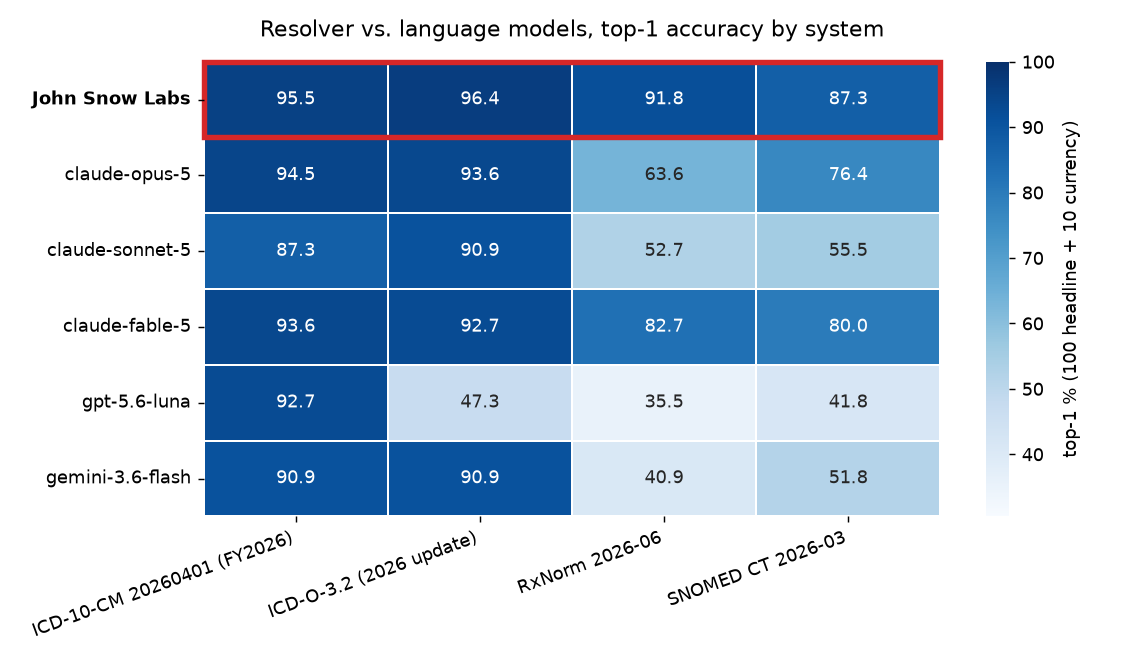

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import re

fig, ax = plt.subplots(figsize=(1.7 * len(pivot.columns) + 2, 0.6 * len(pivot.index) + 1.5))

# Stretch the color range to the data actually in front of us, rather than a fixed 0-100 --
# with every score already clustered in the 30-100 band, a full 0-100 scale would waste most
# of the color range and understate real differences.
vmin = max(0, pivot.values.min() - 5)

# Display-only relabeling: the resolver's row reads "John Snow Labs" here (the underlying
# scoring/report data still says "Healthcare NLP resolver", unchanged), and RxNorm/SNOMED CT
# column headers shrink to just the tested release's year and month -- their full label stays
# useful everywhere else in this notebook, it's only this chart that wants it short. Works for
# whatever dates you're running against, not hardcoded to this run's own release.
def short_system_label(label):
    m = re.search(r"(20\d{6})", label)
    if m and (label.startswith("RxNorm") or label.startswith("SNOMED")):
        d = m.group(1)
        name = "RxNorm" if label.startswith("RxNorm") else "SNOMED CT"
        return f"{name} {d[:4]}-{d[4:6]}"
    return label

plot_pivot = pivot.rename(index={"Healthcare NLP resolver": "John Snow Labs"}, columns=short_system_label)

sns.heatmap(
    plot_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=vmin,
    vmax=100,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "top-1 % (100 headline + 10 currency)"},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Resolver vs. language models, top-1 accuracy by system", pad=14)

for label in ax.get_yticklabels():
    if label.get_text() == "John Snow Labs":
        label.set_fontweight("bold")

# Outline the resolver's own row -- the one row this whole notebook exists to place in
# context -- so it reads at a glance, on top of the color scale rather than instead of it.
resolver_row = list(plot_pivot.index).index("John Snow Labs")
ax.add_patch(patches.Rectangle(
    (0, resolver_row), len(plot_pivot.columns), 1,
    fill=False, edgecolor="#d62728", linewidth=3, clip_on=False,
))

plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Benchmark evaluation

The exact numbers above will vary a little every time this notebook runs, but not for the same
reason on both sides of the table.
- Every resolver here loads through `.pretrained()`: the same
model, matched against the same official gold codes, gives the same answer every time you call
it, regardless of when or how often you run it.
- A language model's API call is not like that:
the same prompt sent to the same model on two different runs can come back with a different
answer.
- Whatever your own numbers turn out to be, the resolver's advantage over general-purpose
language models holds for a reason that has nothing to do with any single run: a resolver is
trained directly on the coding system's own vocabulary, so it works from the actual domain
knowledge a language model can only approximate from whatever coding examples happened to appear
in its training data.

That domain-knowledge gap is not the same size on every system, and the pattern is worth knowing
before reading your own results. It tracks how memorable a coding system's own codes are.
- SNOMED CT concept IDs and RxNorm RxCUIs are long, arbitrary numeric strings with nothing in the number
itself hinting at what it means, so no amount of general medical knowledge lets a language model
reason its way to the right one -- this is where the gap runs widest.
- ICD-10-CM and ICD-O codes are shorter and partly mnemonic (a diabetes code starting with "E11," a chapter tied to a body
system), so a language model that has memorized enough of the public coding manual gets closer,
and the two sides finish nearer together.

Beyond the raw top-1 numbers, general-purpose language models tend to fail in a few recognizable
ways on a benchmark like this one:
- confusing one concept type for a related but different one (a
brand name resolved to its bare ingredient, a substance resolved to the product that contains
it),
- missing a code added after the model's own training cutoff, mistaking a retired code for a
still-current one, and,
- on occasion, returning a code that does not exist in the vocabulary at
all -- a fabrication rather than a near miss.

A resolver's output is always drawn from its own
trained index of real, valid codes, so that last failure mode does not happen to it: a resolver's miss is still a real, semantically related code, never an invented one.

The report's own
`invalid_%` column measures exactly this, computed the same way for the resolver and for every
language model, on your own data rather than taken on faith.
